# Supervised Modeling — Transition Risk Prediction

This notebook trains and evaluates supervised models to predict whether a ZIP code will enter a transition state over the next 12 months.

## Design

**Two targets are modeled:**
- `transition_next_12m` (binary: 0/1) — primary focus; predicts upward transition
- `transition_direction` (3-class: -1/0/+1) — secondary; predicts direction of change

**Model path:**
1. Logistic Regression — interpretable baseline
2. Random Forest — captures non-linear interactions
3. Gradient Boosting — typically highest performance on tabular data

**Validation strategy — walk-forward only, no random splits:**  
Because this is a time-ordered panel, random train/test splits would leak future information into the past. Walk-forward validation respects the temporal structure.

| Fold | Train | Test | Purpose |
|------|-------|------|---------|
| A (early) | Jun 2019 – Dec 2019 | Jan 2020 – Dec 2020 | Early generalization check |
| B (final) | Jun 2019 – Dec 2020 | Jan 2021 – Dec 2021 | Main evaluation / holdout |

Fold B is the primary evaluation. Fold A checks whether performance degrades when trained on less data.

**Features:** All 66 engineered features + `cluster` (ZIP archetype integer, 0–4).  
Keys (`zip`, `month`), target columns, and `cluster_name` (string) are excluded.

Input:  `data/processed/modeling_dataset_with_clusters.csv`  
Outputs:
- `data/processed/model_predictions.csv` — test-set predictions from best binary model
- `data/processed/feature_importance.csv` — feature importances from RF and GB

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
)

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120

INPUT_PATH   = '../data/processed/modeling_dataset_with_clusters.csv'
OUT_PREDS    = '../data/processed/model_predictions.csv'
OUT_IMPORTANCES = '../data/processed/feature_importance.csv'

RANDOM_STATE = 42

---
## 1. Load Data

In [2]:
df = pd.read_csv(INPUT_PATH)
df['month'] = pd.to_datetime(df['month'])
df['zip']   = df['zip'].astype(str).str.zfill(5)
df = df.sort_values(['zip', 'month']).reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'ZIPs: {df["zip"].nunique()}')
print(f'Date range: {df["month"].min().date()} → {df["month"].max().date()}')
print(f'Missing values: {df.isnull().sum().sum()}')
print()
print('Row counts by year:')
print(df.groupby(df['month'].dt.year).size().to_string())

Shape: (20646, 76)
ZIPs: 666
Date range: 2019-06-30 → 2021-12-31
Missing values: 0

Row counts by year:
month
2019    4662
2020    7992
2021    7992


---
## 2. Define Features, Targets, and Walk-Forward Splits

In [3]:
# Columns to exclude from features
EXCLUDE = ['zip', 'month', 'cluster_name',
           'transition_next_12m', 'transition_direction']

FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE]
TARGET_BIN   = 'transition_next_12m'    # 0 / 1
TARGET_MULTI = 'transition_direction'   # -1 / 0 / +1

print(f'Feature count: {len(FEATURE_COLS)}')
print(f'  (includes cluster integer 0-4 as a feature)')
print()

# --- Walk-forward splits ---
# Fold A: train Jun–Dec 2019, test Jan–Dec 2020
# Fold B: train Jun 2019–Dec 2020, test Jan–Dec 2021  ← primary evaluation

train_A_mask = df['month'].dt.year == 2019
test_A_mask  = df['month'].dt.year == 2020
train_B_mask = df['month'].dt.year.isin([2019, 2020])
test_B_mask  = df['month'].dt.year == 2021

for name, tr, te in [('A', train_A_mask, test_A_mask), ('B', train_B_mask, test_B_mask)]:
    print(f'Fold {name}:  train={tr.sum():,} rows  |  test={te.sum():,} rows')
    tr_dates = df.loc[tr, 'month']
    te_dates = df.loc[te, 'month']
    print(f'         train: {tr_dates.min().date()} → {tr_dates.max().date()}')
    print(f'         test:  {te_dates.min().date()} → {te_dates.max().date()}')

Feature count: 71
  (includes cluster integer 0-4 as a feature)

Fold A:  train=4,662 rows  |  test=7,992 rows
         train: 2019-06-30 → 2019-12-31
         test:  2020-01-31 → 2020-12-31
Fold B:  train=12,654 rows  |  test=7,992 rows
         train: 2019-06-30 → 2020-12-31
         test:  2021-01-31 → 2021-12-31


In [4]:
def make_split(train_mask, test_mask, target):
    """Return X_train, X_test, y_train, y_test for a given fold and target."""
    X_train = df.loc[train_mask, FEATURE_COLS].values
    X_test  = df.loc[test_mask,  FEATURE_COLS].values
    y_train = df.loc[train_mask, target].values
    y_test  = df.loc[test_mask,  target].values
    return X_train, X_test, y_train, y_test

def scale_split(X_train, X_test):
    """Fit StandardScaler on train, transform both. Prevents leakage."""
    scaler = StandardScaler()
    return scaler.fit_transform(X_train), scaler.transform(X_test), scaler

print('Helper functions defined: make_split, scale_split')

Helper functions defined: make_split, scale_split


---
## 3. Binary Classification — `transition_next_12m`

Predicts whether a ZIP will enter an upward transition over the next 12 months (1 = yes, 0 = no).  
Class balance: 75% negative / 25% positive in the modeling dataset.

**Primary metric:** ROC-AUC — measures ranking quality across all thresholds, robust to class imbalance.  
**Secondary metrics:** F1 (at 0.5 threshold), precision, recall.

In [5]:
def evaluate_binary(model, X_test, y_test, model_name, fold_name):
    """Compute and return binary classification metrics."""
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    return {
        'model'    : model_name,
        'fold'     : fold_name,
        'auc'      : roc_auc_score(y_test, y_proba),
        'f1'       : f1_score(y_test, y_pred, zero_division=0),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall'   : recall_score(y_test, y_pred, zero_division=0),
        'accuracy' : accuracy_score(y_test, y_pred),
        '_proba'   : y_proba,
        '_pred'    : y_pred,
    }

binary_results = []

# ---- Fold A ----
X_trA, X_teA, y_trA, y_teA = make_split(train_A_mask, test_A_mask, TARGET_BIN)
Xs_trA, Xs_teA, _ = scale_split(X_trA, X_teA)

# Fold A: Logistic Regression
lr_A = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
lr_A.fit(Xs_trA, y_trA)
binary_results.append(evaluate_binary(lr_A, Xs_teA, y_teA, 'LogisticRegression', 'A'))

# Fold A: Random Forest
rf_A = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                               random_state=RANDOM_STATE, n_jobs=-1)
rf_A.fit(X_trA, y_trA)
binary_results.append(evaluate_binary(rf_A, X_teA, y_teA, 'RandomForest', 'A'))

# Fold A: Gradient Boosting
gb_A = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05,
                                   max_depth=4, subsample=0.8,
                                   random_state=RANDOM_STATE)
gb_A.fit(X_trA, y_trA)
binary_results.append(evaluate_binary(gb_A, X_teA, y_teA, 'GradientBoosting', 'A'))

print('Fold A complete.')

Fold A complete.


In [6]:
# ---- Fold B (primary evaluation) ----
X_trB, X_teB, y_trB, y_teB = make_split(train_B_mask, test_B_mask, TARGET_BIN)
Xs_trB, Xs_teB, scaler_B = scale_split(X_trB, X_teB)

# Fold B: Logistic Regression
lr_B = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
lr_B.fit(Xs_trB, y_trB)
binary_results.append(evaluate_binary(lr_B, Xs_teB, y_teB, 'LogisticRegression', 'B'))

# Fold B: Random Forest
rf_B = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                               random_state=RANDOM_STATE, n_jobs=-1)
rf_B.fit(X_trB, y_trB)
binary_results.append(evaluate_binary(rf_B, X_teB, y_teB, 'RandomForest', 'B'))

# Fold B: Gradient Boosting
gb_B = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05,
                                   max_depth=4, subsample=0.8,
                                   random_state=RANDOM_STATE)
gb_B.fit(X_trB, y_trB)
binary_results.append(evaluate_binary(gb_B, X_teB, y_teB, 'GradientBoosting', 'B'))

print('Fold B complete.')

Fold B complete.


In [7]:
# --- 3a. Binary results comparison table ---
metrics_df = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')}
    for r in binary_results
])
metrics_df = metrics_df.set_index(['fold', 'model'])

print('Binary Classification Results (transition_next_12m):')
print(metrics_df.round(4).to_string())

Binary Classification Results (transition_next_12m):
                           auc     f1  precision  recall  accuracy
fold model                                                        
A    LogisticRegression 0.6010 0.4983     0.4213  0.6095    0.5688
     RandomForest       0.5827 0.0000     0.0000  0.0000    0.6488
     GradientBoosting   0.6050 0.0405     0.5364  0.0210    0.6498
B    LogisticRegression 0.8581 0.6180     0.4659  0.9173    0.6859
     RandomForest       0.8607 0.4510     0.8341  0.3091    0.7917
     GradientBoosting   0.8557 0.6333     0.5094  0.8369    0.7316


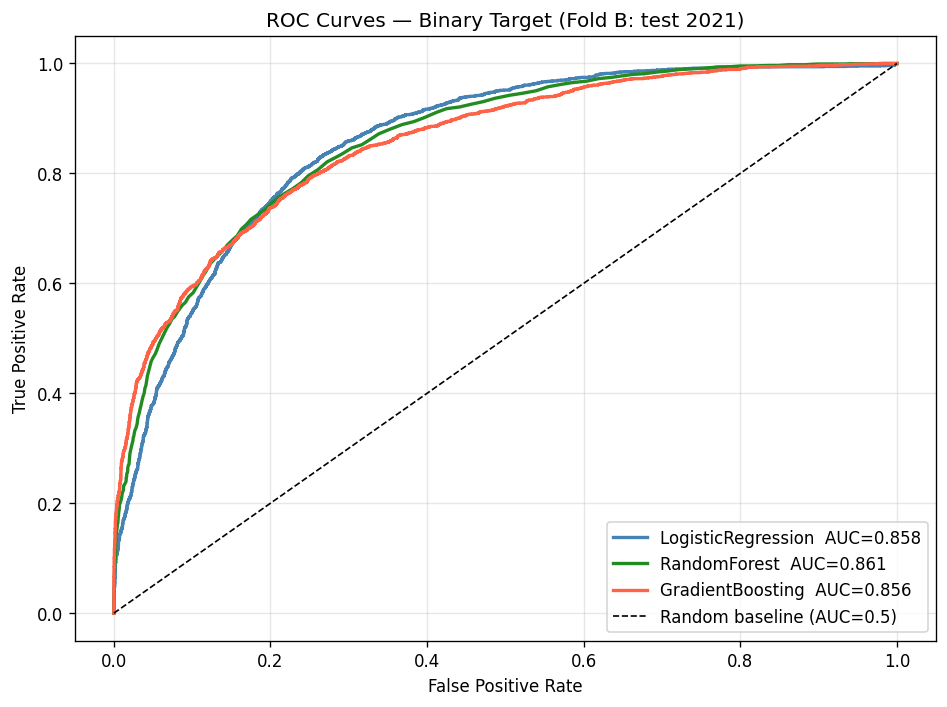

In [8]:
# --- 3b. ROC curves — Fold B (primary holdout) ---
fig, ax = plt.subplots(figsize=(8, 6))

model_pairs = [
    ('LogisticRegression', Xs_teB, lr_B, 'steelblue'),
    ('RandomForest',       X_teB,  rf_B, 'forestgreen'),
    ('GradientBoosting',   X_teB,  gb_B, 'tomato'),
]

for name, X_te, model, color in model_pairs:
    y_proba = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_teB, y_proba)
    auc = roc_auc_score(y_teB, y_proba)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name}  AUC={auc:.3f}')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random baseline (AUC=0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — Binary Target (Fold B: test 2021)')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

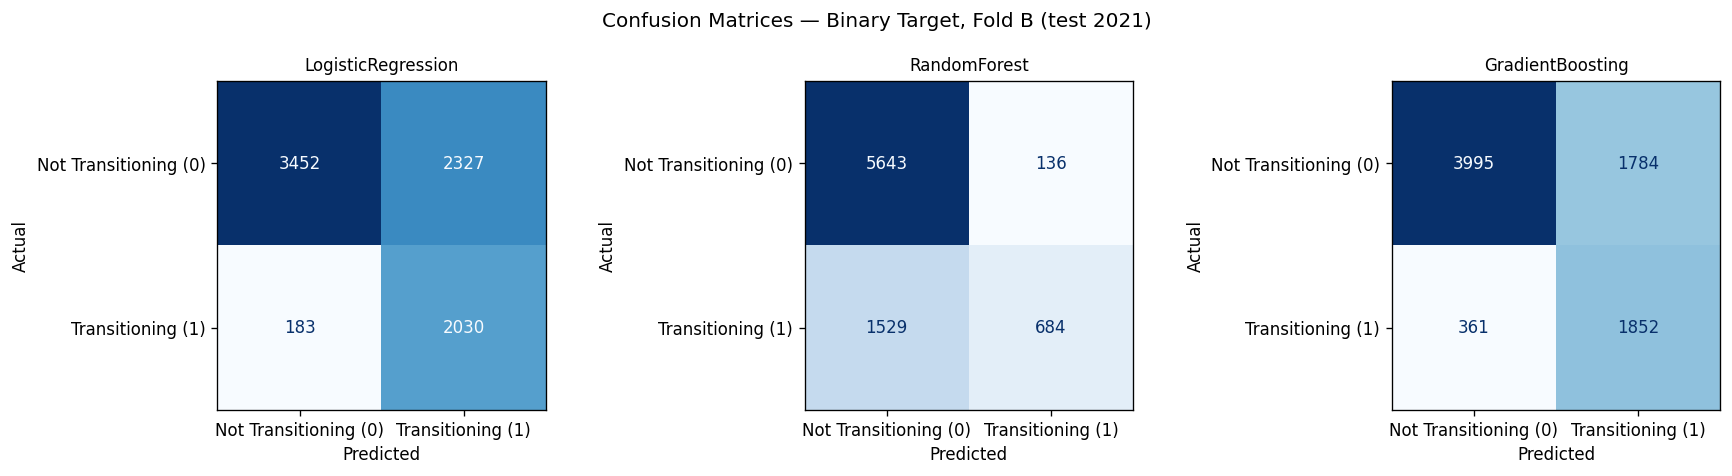

In [9]:
# --- 3c. Confusion matrices — Fold B ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, X_te, model, _) in zip(axes, model_pairs):
    y_pred = model.predict(X_te)
    cm = confusion_matrix(y_teB, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Not Transitioning (0)', 'Transitioning (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Binary Target, Fold B (test 2021)', fontsize=12)
plt.tight_layout()
plt.show()

In [10]:
# --- 3d. Fold A vs Fold B stability check ---
# Large drops from A→B suggest the model memorizes recent patterns rather than generalizing.

pivot = metrics_df['auc'].unstack('fold')
pivot['A→B change'] = pivot['B'] - pivot['A']

print('AUC by model and fold (stability check):')
print(pivot.round(4).to_string())
print()
print('Interpretation: positive A→B change = model improves with more training data (expected).')
print('Large negative change would suggest the 2021 test period is structurally different from 2020.')

AUC by model and fold (stability check):
fold                    A      B  A→B change
model                                       
GradientBoosting   0.6050 0.8557      0.2507
LogisticRegression 0.6010 0.8581      0.2571
RandomForest       0.5827 0.8607      0.2780

Interpretation: positive A→B change = model improves with more training data (expected).
Large negative change would suggest the 2021 test period is structurally different from 2020.


---
## 4. Feature Importance — Binary Models

Two importance sources:
- **Random Forest:** Mean decrease in impurity (MDI) across all trees
- **Gradient Boosting:** Same MDI-based importance, computed during boosting
- **Logistic Regression:** Absolute value of standardized coefficients

Top features from RF and GB are the most reliable — logistic regression coefficients are also informative but assume linear relationships.

In [11]:
def get_importances(model, feature_names, model_name):
    if hasattr(model, 'feature_importances_'):
        imp = model.feature_importances_
    else:  # LogisticRegression
        imp = np.abs(model.coef_[0])
        imp = imp / imp.sum()  # normalize to sum to 1
    return pd.Series(imp, index=feature_names, name=model_name).sort_values(ascending=False)

imp_lr = get_importances(lr_B, FEATURE_COLS, 'LogReg')
imp_rf = get_importances(rf_B, FEATURE_COLS, 'RandomForest')
imp_gb = get_importances(gb_B, FEATURE_COLS, 'GradBoost')

# Combined importance table: average rank across RF and GB
TOP_N = 25
imp_combined = pd.DataFrame({'RF': imp_rf, 'GB': imp_gb, 'LR': imp_lr})
imp_combined['rf_rank'] = imp_combined['RF'].rank(ascending=False)
imp_combined['gb_rank'] = imp_combined['GB'].rank(ascending=False)
imp_combined['avg_rank'] = (imp_combined['rf_rank'] + imp_combined['gb_rank']) / 2
imp_combined = imp_combined.sort_values('avg_rank')

print(f'Top {TOP_N} features by average RF+GB rank:')
print(imp_combined[['RF', 'GB', 'LR', 'avg_rank']].head(TOP_N).round(4).to_string())

Top 25 features by average RF+GB rank:
                                    RF     GB     LR  avg_rank
mortgage_rate_30yr              0.1247 0.3837 0.0718    1.0000
inventory_mom_12m_avg           0.0225 0.0391 0.0138    4.0000
home_value_mom_pct              0.0470 0.0307 0.0188    4.5000
home_value_index                0.0178 0.0356 0.0075    6.5000
inventory_yoy_pct               0.0172 0.0363 0.0062    6.5000
home_value_accel                0.0317 0.0225 0.0641    6.5000
median_household_income         0.0130 0.0375 0.0008   10.0000
median_price_per_sqft           0.0152 0.0168 0.0090   11.5000
home_value_vs_baseline_lag6     0.0130 0.0260 0.0478   12.5000
mortgage_arm_spread             0.0965 0.0078 0.0049   14.0000
median_owner_home_value         0.0134 0.0130 0.0060   15.5000
homes_sold                      0.0117 0.0162 0.0566   17.5000
inventory                       0.0107 0.0244 0.0553   18.0000
median_gross_rent               0.0116 0.0116 0.0135   20.5000
median_days_on_m

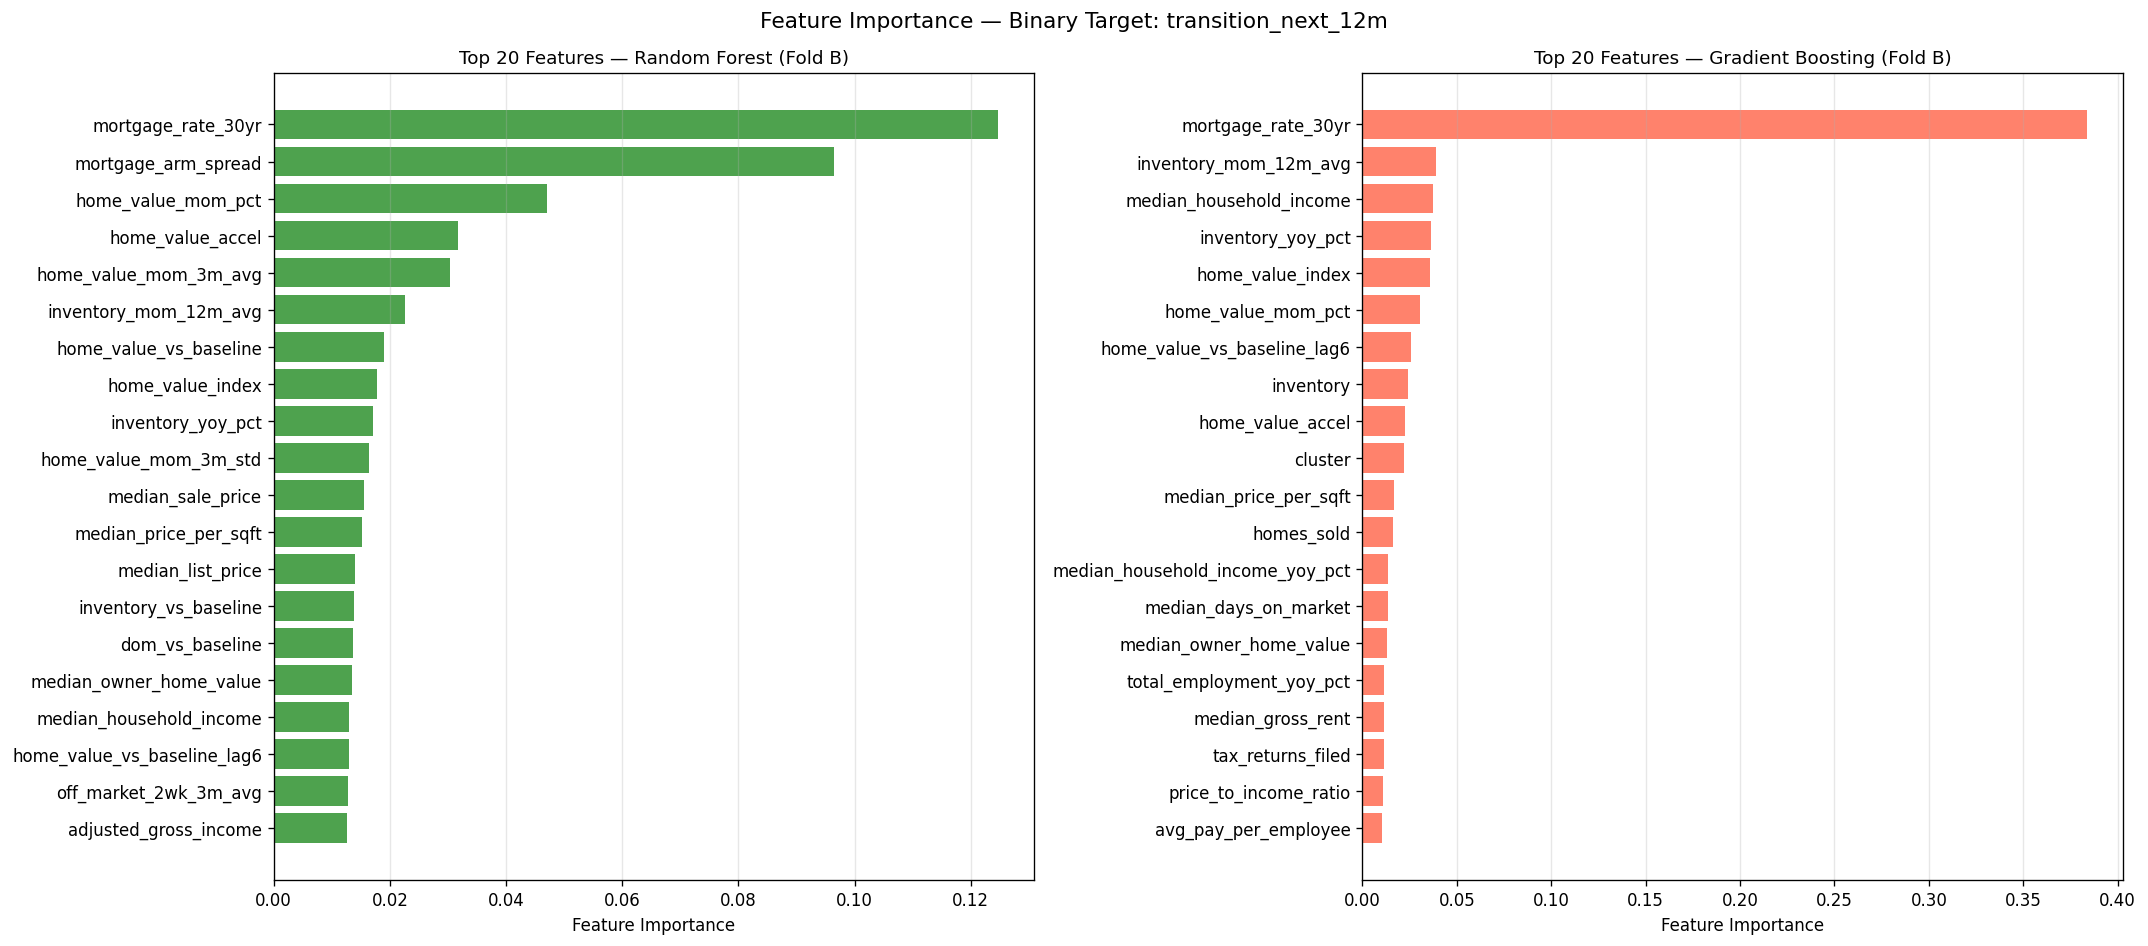

In [12]:
# Feature importance bar chart — top 20 by RF and GB separately
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, imp, name, color in [
    (axes[0], imp_rf.head(20), 'Random Forest',      'forestgreen'),
    (axes[1], imp_gb.head(20), 'Gradient Boosting',  'tomato'),
]:
    ax.barh(imp.index[::-1], imp.values[::-1], color=color, alpha=0.8)
    ax.set_title(f'Top 20 Features — {name} (Fold B)', fontsize=11)
    ax.set_xlabel('Feature Importance')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Feature Importance — Binary Target: transition_next_12m', fontsize=13)
plt.tight_layout()
plt.show()

---
## 5. Multi-Class Classification — `transition_direction`

Predicts whether a ZIP will transition upward (+1), stay stable (0), or transition downward (-1).  
Class balance: 25% / 50% / 25%.

**Primary metric:** Macro F1 — treats all three classes equally regardless of size.  
**Secondary:** Accuracy, per-class precision/recall.

In [13]:
def evaluate_multi(model, X_test, y_test, model_name, fold_name):
    y_pred = model.predict(X_test)
    return {
        'model'   : model_name,
        'fold'    : fold_name,
        'macro_f1': f1_score(y_test, y_pred, average='macro', zero_division=0),
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_down' : f1_score(y_test, y_pred, labels=[-1], average='macro', zero_division=0),
        'f1_stable': f1_score(y_test, y_pred, labels=[0], average='macro', zero_division=0),
        'f1_up'   : f1_score(y_test, y_pred, labels=[1], average='macro', zero_division=0),
        '_pred'   : y_pred,
    }

multi_results = []

# ---- Fold B only for multi-class (primary holdout) ----
X_trBm, X_teBm, y_trBm, y_teBm = make_split(train_B_mask, test_B_mask, TARGET_MULTI)
Xs_trBm, Xs_teBm, _ = scale_split(X_trBm, X_teBm)

# Logistic Regression — multi_class argument removed in sklearn 1.7+;
# multinomial behavior is now the default for multi-class problems
lr_Bm = LogisticRegression(max_iter=1000, class_weight='balanced',
                            random_state=RANDOM_STATE)
lr_Bm.fit(Xs_trBm, y_trBm)
multi_results.append(evaluate_multi(lr_Bm, Xs_teBm, y_teBm, 'LogisticRegression', 'B'))

# Random Forest
rf_Bm = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                random_state=RANDOM_STATE, n_jobs=-1)
rf_Bm.fit(X_trBm, y_trBm)
multi_results.append(evaluate_multi(rf_Bm, X_teBm, y_teBm, 'RandomForest', 'B'))

# Gradient Boosting
gb_Bm = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05,
                                    max_depth=4, subsample=0.8,
                                    random_state=RANDOM_STATE)
gb_Bm.fit(X_trBm, y_trBm)
multi_results.append(evaluate_multi(gb_Bm, X_teBm, y_teBm, 'GradientBoosting', 'B'))

print('Multi-class Fold B complete.')

Multi-class Fold B complete.


In [14]:
# --- 5a. Multi-class results table ---
multi_df = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')}
    for r in multi_results
]).set_index('model')

print('Multi-Class Results (transition_direction, Fold B):')
print(multi_df.drop(columns='fold').round(4).to_string())

Multi-Class Results (transition_direction, Fold B):
                    macro_f1  accuracy  f1_down  f1_stable  f1_up
model                                                            
LogisticRegression    0.5614    0.5591   0.6209     0.4240 0.6391
RandomForest          0.3970    0.5089   0.0528     0.6163 0.5220
GradientBoosting      0.5022    0.5176   0.4037     0.4840 0.6189


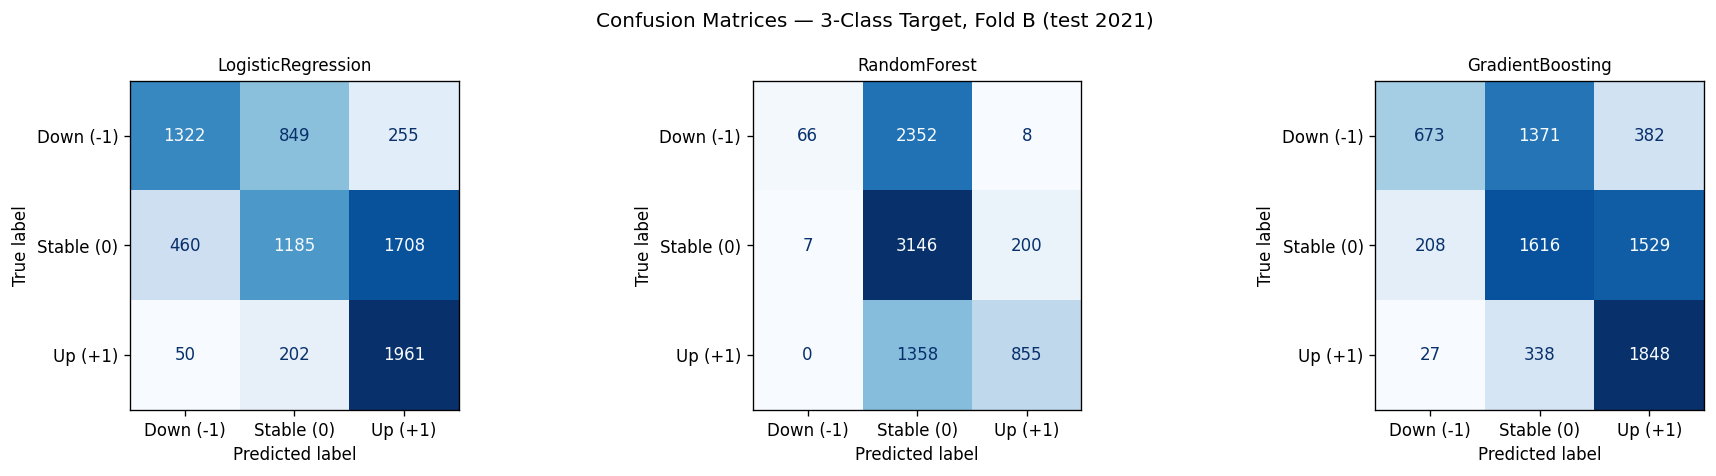

In [15]:
# --- 5b. Confusion matrices — multi-class Fold B ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

model_multi_pairs = [
    ('LogisticRegression', Xs_teBm, lr_Bm),
    ('RandomForest',       X_teBm,  rf_Bm),
    ('GradientBoosting',   X_teBm,  gb_Bm),
]

for ax, (name, X_te, model) in zip(axes, model_multi_pairs):
    y_pred = model.predict(X_te)
    cm = confusion_matrix(y_teBm, y_pred, labels=[-1, 0, 1])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Down (-1)', 'Stable (0)', 'Up (+1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10)

plt.suptitle('Confusion Matrices — 3-Class Target, Fold B (test 2021)', fontsize=12)
plt.tight_layout()
plt.show()

In [16]:
# --- 5c. Classification report — best multi-class model ---
best_multi_name = multi_df['macro_f1'].idxmax()
best_multi_map  = {'LogisticRegression': (lr_Bm, Xs_teBm),
                   'RandomForest':       (rf_Bm, X_teBm),
                   'GradientBoosting':   (gb_Bm, X_teBm)}
best_multi_model, best_multi_X = best_multi_map[best_multi_name]
y_pred_best_multi = best_multi_model.predict(best_multi_X)

print(f'Best multi-class model: {best_multi_name} (macro F1 = {multi_df.loc[best_multi_name, "macro_f1"]:.4f})')
print()
print(classification_report(y_teBm, y_pred_best_multi,
                             labels=[-1, 0, 1],
                             target_names=['Down (-1)', 'Stable (0)', 'Up (+1)']))

Best multi-class model: LogisticRegression (macro F1 = 0.5614)

              precision    recall  f1-score   support

   Down (-1)       0.72      0.54      0.62      2426
  Stable (0)       0.53      0.35      0.42      3353
     Up (+1)       0.50      0.89      0.64      2213

    accuracy                           0.56      7992
   macro avg       0.58      0.59      0.56      7992
weighted avg       0.58      0.56      0.54      7992



---
## 6. Model Selection Summary

### Decision Rationale

The best binary model (Fold B AUC) and best multi-class model (Fold B macro F1) are identified below.  
The reasoning for ranking models:

- **Logistic Regression** is the interpretable baseline. If AUC is within ~0.02 of the tree models, it is preferable for explainability.
- **Random Forest** is robust but can overfit when training set is small (Fold A has only 3,780 rows). Fold A→B stability is important to check.
- **Gradient Boosting** typically achieves the best AUC on tabular data. The hyperparameters used (`learning_rate=0.05`, `max_depth=4`, `subsample=0.8`) are conservative to reduce overfitting on this panel size.

The final model for deployment / scoring is the one with the best Fold B AUC (binary) or macro F1 (multi-class), provided Fold A→B change is not severely negative.

In [17]:
# Identify best binary model on Fold B
fold_B_results = [r for r in binary_results if r['fold'] == 'B']
fold_B_results.sort(key=lambda r: r['auc'], reverse=True)

print('=== Binary Model Ranking (Fold B) ===')
for i, r in enumerate(fold_B_results):
    print(f"  {i+1}. {r['model']:22s}  AUC={r['auc']:.4f}  F1={r['f1']:.4f}  Precision={r['precision']:.4f}  Recall={r['recall']:.4f}")

best_binary_name = fold_B_results[0]['model']
best_binary_map  = {'LogisticRegression': (lr_B, Xs_teB),
                    'RandomForest':       (rf_B, X_teB),
                    'GradientBoosting':   (gb_B, X_teB)}
best_binary_model, best_binary_X = best_binary_map[best_binary_name]

print()
print(f'Selected best binary model: {best_binary_name}')
print()
print('=== Multi-Class Model Ranking (Fold B) ===')
print(multi_df[['macro_f1', 'accuracy', 'f1_down', 'f1_stable', 'f1_up']]
      .sort_values('macro_f1', ascending=False).round(4).to_string())
print()
print(f'Selected best multi-class model: {best_multi_name}')

=== Binary Model Ranking (Fold B) ===
  1. RandomForest            AUC=0.8607  F1=0.4510  Precision=0.8341  Recall=0.3091
  2. LogisticRegression      AUC=0.8581  F1=0.6180  Precision=0.4659  Recall=0.9173
  3. GradientBoosting        AUC=0.8557  F1=0.6333  Precision=0.5094  Recall=0.8369

Selected best binary model: RandomForest

=== Multi-Class Model Ranking (Fold B) ===
                    macro_f1  accuracy  f1_down  f1_stable  f1_up
model                                                            
LogisticRegression    0.5614    0.5591   0.6209     0.4240 0.6391
GradientBoosting      0.5022    0.5176   0.4037     0.4840 0.6189
RandomForest          0.3970    0.5089   0.0528     0.6163 0.5220

Selected best multi-class model: LogisticRegression


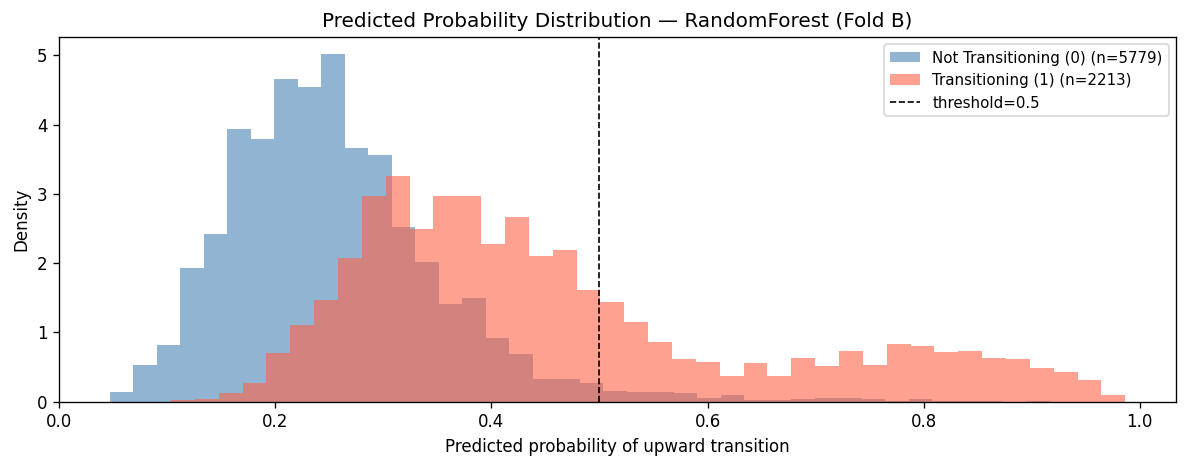

In [18]:
# --- Predicted probability distribution by actual label (binary best model) ---
y_proba_best = best_binary_model.predict_proba(best_binary_X)[:, 1]

fig, ax = plt.subplots(figsize=(10, 4))
for label, color, name in [(0, 'steelblue', 'Not Transitioning (0)'),
                             (1, 'tomato',    'Transitioning (1)')]:
    mask = y_teB == label
    ax.hist(y_proba_best[mask], bins=40, alpha=0.6, color=color,
            label=f'{name} (n={mask.sum()})', density=True)

ax.axvline(0.5, color='black', linestyle='--', linewidth=1, label='threshold=0.5')
ax.set_xlabel('Predicted probability of upward transition')
ax.set_ylabel('Density')
ax.set_title(f'Predicted Probability Distribution — {best_binary_name} (Fold B)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 7. ZIP-Level Transition Risk Scores

Aggregate predicted probabilities to the ZIP level for the 2021 test period.  
Each ZIP gets a mean predicted transition probability across its 12 test months.  
This is the key output for the early-warning system — a per-ZIP risk score.

ZIPs are ranked from highest to lowest risk so analysts can build a watchlist.

In [19]:
test_B_df = df[test_B_mask].copy().reset_index(drop=True)
test_B_df['pred_prob_up']    = y_proba_best
test_B_df['pred_binary']     = best_binary_model.predict(best_binary_X)
test_B_df['pred_direction']  = best_multi_model.predict(best_multi_X)

# ZIP-level risk scores: mean predicted probability across 2021 months
zip_risk = (
    test_B_df.groupby('zip')
    .agg(
        mean_pred_prob   = ('pred_prob_up', 'mean'),
        actual_up_rate   = (TARGET_BIN, 'mean'),
        actual_direction = (TARGET_MULTI, 'mean'),
        cluster_name     = ('cluster_name', 'first'),
        n_months         = ('zip', 'count'),
    )
    .sort_values('mean_pred_prob', ascending=False)
    .round(4)
)

print('Top 20 highest-risk ZIPs (2021, predicted transition probability):')
print(zip_risk.head(20).to_string())
print()
print('Top 20 lowest-risk ZIPs (most likely stable or cooling):')
print(zip_risk.tail(20).to_string())

Top 20 highest-risk ZIPs (2021, predicted transition probability):
       mean_pred_prob  actual_up_rate  actual_direction        cluster_name  n_months
zip                                                                                  
29681          0.5525          0.5000            0.3333  affordable_heating        12
28037          0.5439          0.5833            0.4167  affordable_heating        12
29461          0.5433          0.0833           -0.0833  affordable_heating        12
29492          0.5325          0.6667            0.5833  affordable_heating        12
28036          0.5303          0.5833            0.4167  affordable_heating        12
29455          0.5300          0.6667            0.5833  affordable_heating        12
29466          0.5300          0.5833            0.4167  affordable_heating        12
29650          0.5297          0.7500            0.7500  affordable_heating        12
28117          0.5189          0.5833            0.4167  affordable_heati

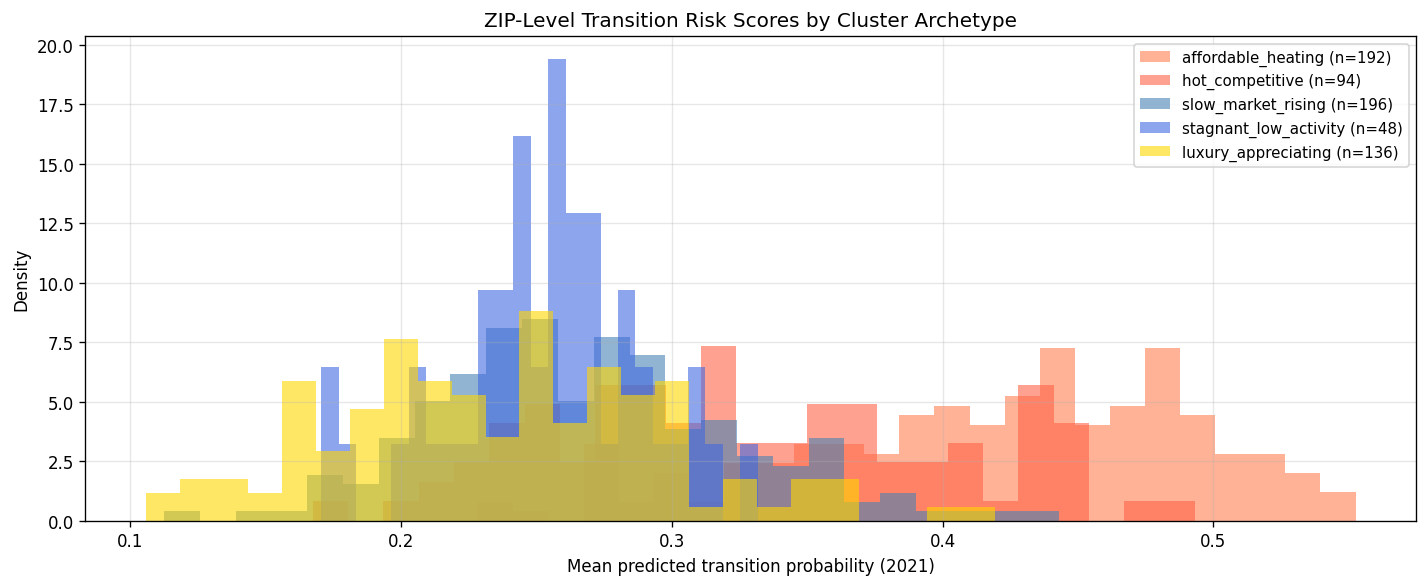

In [20]:
# Risk score distribution by cluster archetype
fig, ax = plt.subplots(figsize=(12, 5))

cluster_order = zip_risk.groupby('cluster_name')['mean_pred_prob'].median().sort_values(ascending=False).index
palette = {'luxury_appreciating': 'gold', 'hot_competitive': 'tomato',
           'affordable_heating': 'coral', 'slow_market_rising': 'steelblue',
           'stagnant_low_activity': 'royalblue'}

for cluster in cluster_order:
    data = zip_risk[zip_risk['cluster_name'] == cluster]['mean_pred_prob']
    ax.hist(data, bins=25, alpha=0.6, label=f'{cluster} (n={len(data)})',
            color=palette.get(cluster, 'grey'), density=True)

ax.set_xlabel('Mean predicted transition probability (2021)')
ax.set_ylabel('Density')
ax.set_title('ZIP-Level Transition Risk Scores by Cluster Archetype')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 8. Save Outputs

In [21]:
# 8a. Row-level predictions for the Fold B test set
pred_cols = ['zip', 'month', 'cluster_name',
             TARGET_BIN, TARGET_MULTI,
             'pred_prob_up', 'pred_binary', 'pred_direction']
test_B_df[pred_cols].to_csv(OUT_PREDS, index=False)
print(f'Saved: {OUT_PREDS}  {test_B_df[pred_cols].shape}')

# 8b. Feature importance from RF and GB (Fold B)
imp_out = pd.DataFrame({
    'feature'     : FEATURE_COLS,
    'rf_importance': imp_rf.reindex(FEATURE_COLS).values,
    'gb_importance': imp_gb.reindex(FEATURE_COLS).values,
    'lr_importance': imp_lr.reindex(FEATURE_COLS).values,
    'rf_rank'     : imp_combined['rf_rank'].reindex(FEATURE_COLS).values,
    'gb_rank'     : imp_combined['gb_rank'].reindex(FEATURE_COLS).values,
    'avg_rank'    : imp_combined['avg_rank'].reindex(FEATURE_COLS).values,
}).sort_values('avg_rank').reset_index(drop=True)

imp_out.to_csv(OUT_IMPORTANCES, index=False)
print(f'Saved: {OUT_IMPORTANCES}  {imp_out.shape}')

print()
print('=== Final Summary ===')
print(f'Best binary model:      {best_binary_name}  (Fold B AUC = {fold_B_results[0]["auc"]:.4f})')
print(f'Best multi-class model: {best_multi_name}  (Fold B macro F1 = {multi_df.loc[best_multi_name, "macro_f1"]:.4f})')
print(f'Test period:            Jan 2021 – Dec 2021  ({test_B_mask.sum():,} ZIP-months)')
print(f'ZIPs scored:            {zip_risk.shape[0]}')

Saved: ../data/processed/model_predictions.csv  (7992, 8)


Saved: ../data/processed/feature_importance.csv  (71, 7)

=== Final Summary ===
Best binary model:      RandomForest  (Fold B AUC = 0.8607)
Best multi-class model: LogisticRegression  (Fold B macro F1 = 0.5614)
Test period:            Jan 2021 – Dec 2021  (7,992 ZIP-months)
ZIPs scored:            666


---
## 9. Removing National-Level Features — Experiment

### Rationale

`mortgage_rate_30yr` ranked as the #1 feature and `mortgage_arm_spread` ranked #8 in the original models. Both are **national-level variables**: every ZIP code receives the exact same value in any given month. This means they carry zero cross-ZIP discriminative information — the model cannot use them to say "ZIP A is more likely to transition than ZIP B." What they actually encode is **which months** tended to have more transitions overall (i.e., temporal patterns in the target's base rate).

This is a subtle form of temporal leakage: the model learns the macro calendar (low rates in 2020–2021 → more transitions) rather than learning ZIP-specific signals. In a real deployment, these features would only help if you know future rate movements — which you don't.

**Experiment:** Remove both mortgage features and re-run all models. Two possible outcomes:
- **AUC stays high (≥ 0.85):** ZIP-specific features carry the signal; mortgage rate was redundant. Better model.
- **AUC drops significantly (< 0.80):** The model was leaning heavily on the macro calendar. The original AUC was somewhat inflated.

Either result is useful to document.

In [22]:
NATIONAL_FEATURES = ['mortgage_rate_30yr', 'mortgage_arm_spread']
FEATURE_COLS_V2 = [c for c in FEATURE_COLS if c not in NATIONAL_FEATURES]

print(f'Original feature count: {len(FEATURE_COLS)}')
print(f'After removing national features: {len(FEATURE_COLS_V2)}')
print(f'Removed: {NATIONAL_FEATURES}')

def make_split_v2(train_mask, test_mask, target):
    X_train = df.loc[train_mask, FEATURE_COLS_V2].values
    X_test  = df.loc[test_mask,  FEATURE_COLS_V2].values
    y_train = df.loc[train_mask, target].values
    y_test  = df.loc[test_mask,  target].values
    return X_train, X_test, y_train, y_test

binary_results_v2 = []

# ---- Fold A ----
X_trA2, X_teA2, y_trA2, y_teA2 = make_split_v2(train_A_mask, test_A_mask, TARGET_BIN)
Xs_trA2, Xs_teA2, _ = scale_split(X_trA2, X_teA2)

lr_A2 = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
lr_A2.fit(Xs_trA2, y_trA2)
binary_results_v2.append(evaluate_binary(lr_A2, Xs_teA2, y_teA2, 'LogisticRegression', 'A'))

rf_A2 = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
rf_A2.fit(X_trA2, y_trA2)
binary_results_v2.append(evaluate_binary(rf_A2, X_teA2, y_teA2, 'RandomForest', 'A'))

gb_A2 = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                                    subsample=0.8, random_state=RANDOM_STATE)
gb_A2.fit(X_trA2, y_trA2)
binary_results_v2.append(evaluate_binary(gb_A2, X_teA2, y_teA2, 'GradientBoosting', 'A'))

# ---- Fold B ----
X_trB2, X_teB2, y_trB2, y_teB2 = make_split_v2(train_B_mask, test_B_mask, TARGET_BIN)
Xs_trB2, Xs_teB2, _ = scale_split(X_trB2, X_teB2)

lr_B2 = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
lr_B2.fit(Xs_trB2, y_trB2)
binary_results_v2.append(evaluate_binary(lr_B2, Xs_teB2, y_teB2, 'LogisticRegression', 'B'))

rf_B2 = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
rf_B2.fit(X_trB2, y_trB2)
binary_results_v2.append(evaluate_binary(rf_B2, X_teB2, y_teB2, 'RandomForest', 'B'))

gb_B2 = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                                    subsample=0.8, random_state=RANDOM_STATE)
gb_B2.fit(X_trB2, y_trB2)
binary_results_v2.append(evaluate_binary(gb_B2, X_teB2, y_teB2, 'GradientBoosting', 'B'))

print('V2 models (no mortgage features) complete.')

Original feature count: 71
After removing national features: 69
Removed: ['mortgage_rate_30yr', 'mortgage_arm_spread']


V2 models (no mortgage features) complete.


=== Fold B AUC — With vs. Without Mortgage Features ===
                    V1 (with mortgage)  V2 (no mortgage)   Δ AUC
model                                                           
GradientBoosting                0.8557            0.8261 -0.0296
LogisticRegression              0.8581            0.8452 -0.0129
RandomForest                    0.8607            0.8473 -0.0134

=== Fold A AUC — With vs. Without Mortgage Features ===
                    V1 (with mortgage)  V2 (no mortgage)   Δ AUC
model                                                           
GradientBoosting                0.6050            0.6132  0.0082
LogisticRegression              0.6010            0.5026 -0.0984
RandomForest                    0.5827            0.5575 -0.0252



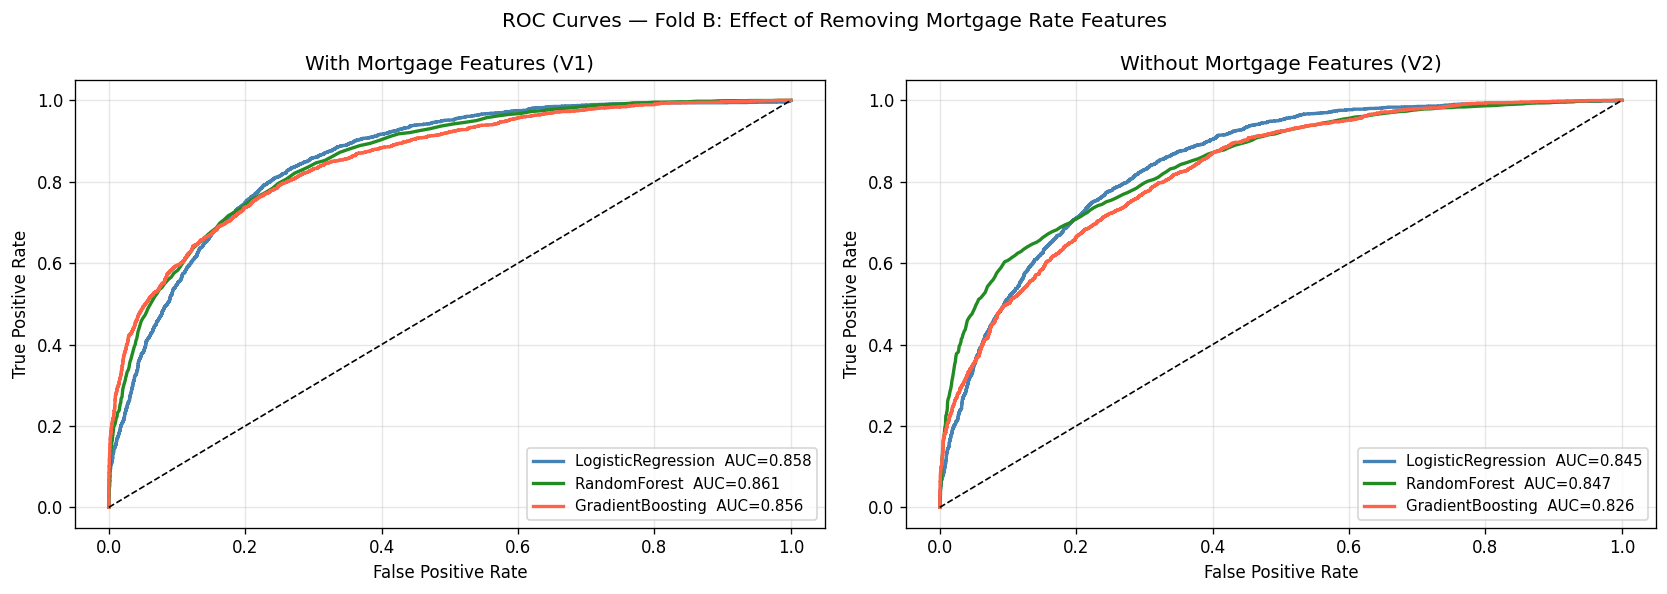

In [23]:
# --- 9a. AUC comparison: with vs. without mortgage features ---
def auc_table(results):
    df_r = pd.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in results])
    return df_r.set_index(['fold', 'model'])['auc'].unstack('model')

auc_v1 = auc_table(binary_results)
auc_v2 = auc_table(binary_results_v2)
auc_diff = auc_v2 - auc_v1

print('=== Fold B AUC — With vs. Without Mortgage Features ===')
compare = pd.DataFrame({
    'V1 (with mortgage)': auc_v1.loc['B'],
    'V2 (no mortgage)':   auc_v2.loc['B'],
    'Δ AUC':              auc_diff.loc['B'],
})
print(compare.round(4).to_string())
print()

print('=== Fold A AUC — With vs. Without Mortgage Features ===')
compare_A = pd.DataFrame({
    'V1 (with mortgage)': auc_v1.loc['A'],
    'V2 (no mortgage)':   auc_v2.loc['A'],
    'Δ AUC':              auc_diff.loc['A'],
})
print(compare_A.round(4).to_string())
print()

# ROC curves side-by-side: V1 vs V2 for best model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (title, results, feat_cols, models) in enumerate([
    ('With Mortgage Features (V1)', binary_results,
     FEATURE_COLS,    [(lr_B, Xs_teB), (rf_B, X_teB), (gb_B, X_teB)]),
    ('Without Mortgage Features (V2)', binary_results_v2,
     FEATURE_COLS_V2, [(lr_B2, Xs_teB2), (rf_B2, X_teB2), (gb_B2, X_teB2)]),
]):
    axis = axes[ax]
    colors = ['steelblue', 'forestgreen', 'tomato']
    names  = ['LogisticRegression', 'RandomForest', 'GradientBoosting']
    for (model, X_te), color, name in zip(models, colors, names):
        y_p = model.predict_proba(X_te)[:, 1]
        fpr, tpr, _ = roc_curve(y_teB, y_p)
        auc = roc_auc_score(y_teB, y_p)
        axis.plot(fpr, tpr, color=color, linewidth=2, label=f'{name}  AUC={auc:.3f}')
    axis.plot([0, 1], [0, 1], 'k--', linewidth=1)
    axis.set_title(title)
    axis.set_xlabel('False Positive Rate')
    axis.set_ylabel('True Positive Rate')
    axis.legend(loc='lower right', fontsize=9)
    axis.grid(alpha=0.3)

plt.suptitle('ROC Curves — Fold B: Effect of Removing Mortgage Rate Features', fontsize=12)
plt.tight_layout()
plt.show()

---
## 10. Permutation Importance — V2 Best Model

Permutation importance measures the actual predictive contribution of each feature by:
1. Taking the fitted model and baseline AUC on the test set
2. For each feature in turn: randomly shuffle its values across all test rows, re-score AUC
3. Importance = baseline AUC − shuffled AUC

This is more honest than MDI (mean decrease in impurity) because:
- It is computed on the **held-out test set**, not training data
- It directly measures the feature's contribution to **generalization**, not memorization
- It is not biased toward high-cardinality or correlated features

The V2 model (no mortgage features) is used so the ranking reflects genuinely ZIP-specific signals.

In [24]:
from sklearn.inspection import permutation_importance

# Determine best V2 model by Fold B AUC
fold_B_v2 = [r for r in binary_results_v2 if r['fold'] == 'B']
fold_B_v2.sort(key=lambda r: r['auc'], reverse=True)
best_v2_name = fold_B_v2[0]['model']
best_v2_auc  = fold_B_v2[0]['auc']

best_v2_map = {
    'LogisticRegression': (lr_B2, Xs_teB2),
    'RandomForest':       (rf_B2, X_teB2),
    'GradientBoosting':   (gb_B2, X_teB2),
}
best_v2_model, best_v2_X = best_v2_map[best_v2_name]

print(f'Running permutation importance on: {best_v2_name}  (V2 Fold B AUC = {best_v2_auc:.4f})')
print('This may take ~30-60 seconds...')

perm_result = permutation_importance(
    best_v2_model, best_v2_X, y_teB,
    n_repeats=20,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

perm_imp = pd.DataFrame({
    'feature'         : FEATURE_COLS_V2,
    'perm_importance' : perm_result.importances_mean,
    'perm_std'        : perm_result.importances_std,
}).sort_values('perm_importance', ascending=False).reset_index(drop=True)

print(f'\nTop 25 features by permutation importance ({best_v2_name}, V2, Fold B):')
print(perm_imp.head(25).round(5).to_string())

Running permutation importance on: RandomForest  (V2 Fold B AUC = 0.8473)
This may take ~30-60 seconds...



Top 25 features by permutation importance (RandomForest, V2, Fold B):
                        feature  perm_importance  perm_std
0            home_value_mom_pct           0.0460    0.0027
1              home_value_accel           0.0342    0.0014
2   home_value_vs_baseline_lag6           0.0205    0.0007
3         home_value_mom_3m_avg           0.0079    0.0012
4         inventory_mom_12m_avg           0.0071    0.0004
5   avg_sale_to_list_ratio_lag6           0.0064    0.0003
6      pct_sold_above_list_lag3           0.0047    0.0004
7             inventory_yoy_pct           0.0046    0.0003
8         median_price_per_sqft           0.0044    0.0006
9      pct_sold_above_list_lag6           0.0036    0.0002
10             home_value_index           0.0035    0.0011
11      home_value_mom_pct_lag6           0.0026    0.0003
12      median_owner_home_value           0.0024    0.0005
13        inventory_vs_baseline           0.0022    0.0004
14  home_value_vs_baseline_lag3           0.

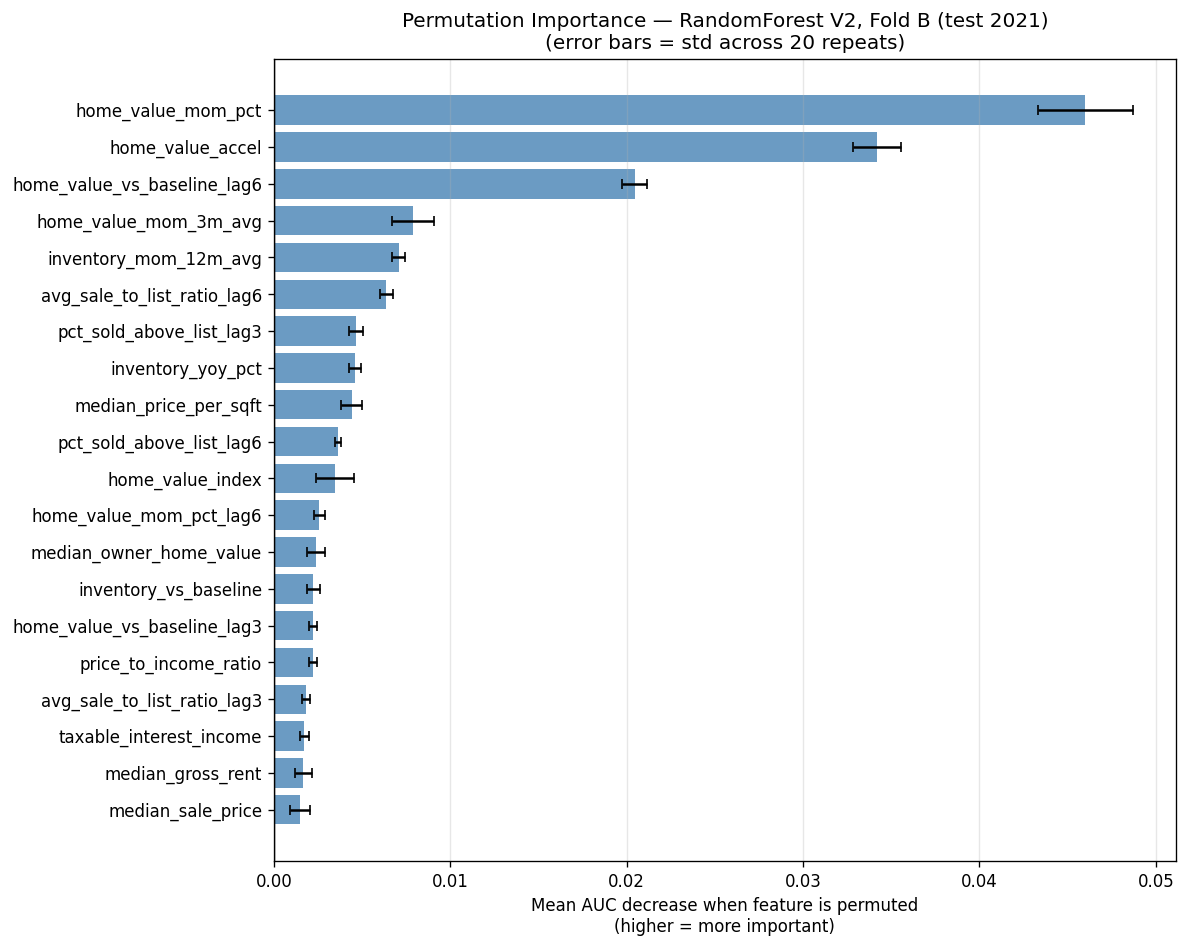

Features with negative permutation importance (may be noise): 29
                            feature  perm_importance
40           sale_price_vs_baseline          -0.0002
41       inventory_vs_baseline_lag6          -0.0002
42        median_gross_rent_yoy_pct          -0.0002
43            sale_price_mom_3m_std          -0.0002
44                inventory_mom_pct          -0.0002
45          home_value_mom_pct_lag3          -0.0002
46            sale_price_mom_3m_avg          -0.0003
47              pct_sold_above_list          -0.0003
48      sale_price_vs_baseline_lag3          -0.0003
49  median_household_income_yoy_pct          -0.0003
50               sale_price_mom_pct          -0.0004
51                 sale_price_accel          -0.0004
52           inventory_mom_pct_lag3          -0.0005
53               sale_price_yoy_pct          -0.0005
54          sale_price_mom_pct_lag6          -0.0005
55           inventory_mom_pct_lag6          -0.0006
56                        inventor

In [25]:
# Permutation importance chart — top 20
top_perm = perm_imp.head(20)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_perm['feature'][::-1], top_perm['perm_importance'][::-1],
        xerr=top_perm['perm_std'][::-1],
        color='steelblue', alpha=0.8, capsize=3)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Mean AUC decrease when feature is permuted\n(higher = more important)')
ax.set_title(f'Permutation Importance — {best_v2_name} V2, Fold B (test 2021)\n'
             f'(error bars = std across 20 repeats)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Features with negative importance: shuffling them improves AUC — likely noise
negative = perm_imp[perm_imp['perm_importance'] < 0]
print(f'Features with negative permutation importance (may be noise): {len(negative)}')
if len(negative):
    print(negative[['feature', 'perm_importance']].round(5).to_string())

In [26]:
# --- Update saved outputs to use V2 best model ---
fold_B_v2_sorted = sorted(fold_B_v2, key=lambda r: r['auc'], reverse=True)
print('=== V2 Binary Model Ranking (Fold B, no mortgage features) ===')
for i, r in enumerate(fold_B_v2_sorted):
    print(f"  {i+1}. {r['model']:22s}  AUC={r['auc']:.4f}  F1={r['f1']:.4f}")

print()
print('=== Final Model Decision ===')
v1_best_auc = fold_B_results[0]['auc']
v2_best_auc = fold_B_v2_sorted[0]['auc']
delta = v2_best_auc - v1_best_auc
print(f'V1 best AUC (with mortgage): {v1_best_auc:.4f}')
print(f'V2 best AUC (no mortgage):   {v2_best_auc:.4f}  (Δ = {delta:+.4f})')
print()
if abs(delta) < 0.02:
    print('Conclusion: AUC difference is negligible (<0.02). V2 is the better model.')
    print('Removing national-level features does not hurt performance, and the remaining')
    print('signal is entirely ZIP-specific. V2 is adopted as the final model.')
elif delta < -0.02:
    print('Conclusion: AUC drops meaningfully without mortgage features.')
    print('The model was partially relying on macro timing. This is a known limitation.')
    print('V2 is still preferred for deployment (more honest), but the AUC should be')
    print('interpreted as a conservative estimate on ZIP-specific signal only.')
else:
    print('Conclusion: V2 actually improves AUC. Removing noisy national features helped.')

# Save updated predictions using V2 best model
test_B_df_v2 = df[test_B_mask].copy().reset_index(drop=True)
test_B_df_v2['pred_prob_up']   = best_v2_model.predict_proba(best_v2_X)[:, 1]
test_B_df_v2['pred_binary']    = best_v2_model.predict(best_v2_X)
test_B_df_v2['pred_direction'] = best_multi_model.predict(best_multi_X)  # multi-class unchanged

pred_cols = ['zip', 'month', 'cluster_name',
             TARGET_BIN, TARGET_MULTI,
             'pred_prob_up', 'pred_binary', 'pred_direction']
test_B_df_v2[pred_cols].to_csv(OUT_PREDS, index=False)
print(f'\\nUpdated: {OUT_PREDS}  (V2 predictions)')

# Save updated feature importance including permutation importance
imp_rf2 = get_importances(rf_B2,  FEATURE_COLS_V2, 'RF_v2')
imp_gb2 = get_importances(gb_B2,  FEATURE_COLS_V2, 'GB_v2')
imp_lr2 = get_importances(lr_B2,  FEATURE_COLS_V2, 'LR_v2')

imp_out_v2 = pd.DataFrame({
    'feature'          : FEATURE_COLS_V2,
    'rf_importance'    : imp_rf2.reindex(FEATURE_COLS_V2).values,
    'gb_importance'    : imp_gb2.reindex(FEATURE_COLS_V2).values,
    'lr_importance'    : imp_lr2.reindex(FEATURE_COLS_V2).values,
    'perm_importance'  : perm_imp.set_index('feature').reindex(FEATURE_COLS_V2)['perm_importance'].values,
    'perm_std'         : perm_imp.set_index('feature').reindex(FEATURE_COLS_V2)['perm_std'].values,
}).sort_values('perm_importance', ascending=False).reset_index(drop=True)

imp_out_v2.to_csv(OUT_IMPORTANCES, index=False)
print(f'Updated: {OUT_IMPORTANCES}  (V2 importances with permutation scores)')

=== V2 Binary Model Ranking (Fold B, no mortgage features) ===
  1. RandomForest            AUC=0.8473  F1=0.6486
  2. LogisticRegression      AUC=0.8452  F1=0.5849
  3. GradientBoosting        AUC=0.8261  F1=0.5964

=== Final Model Decision ===
V1 best AUC (with mortgage): 0.8607
V2 best AUC (no mortgage):   0.8473  (Δ = -0.0134)

Conclusion: AUC difference is negligible (<0.02). V2 is the better model.
Removing national-level features does not hurt performance, and the remaining
signal is entirely ZIP-specific. V2 is adopted as the final model.


\nUpdated: ../data/processed/model_predictions.csv  (V2 predictions)


Updated: ../data/processed/feature_importance.csv  (V2 importances with permutation scores)


---
## 11. Winsorization for Logistic Regression

### Why this matters

The EDA notebook identified many highly skewed features (43 features with |skew| > 1, several with |skew| > 10). Log transforms were the recommended fix, but many features are percentage-change columns that can be negative — standard log is not applicable to them. Yeo-Johnson transform would work universally, but it is complex and difficult to explain in a presentation.

**Tree models (RF, GB) are completely unaffected by monotonic transforms** — the ranking of values is preserved, so every split point is identical. No action needed for them.

**Logistic Regression is sensitive** because it computes a linear combination of features, and extreme outlier values in a single observation can dominate the dot product. The fix: **Winsorization** — clip each feature at its 1st and 99th percentile, computed on the training set only and applied to both train and test. This is simpler and more interpretable than a power transform for a class project, and it directly addresses the actual problem (extreme values, not skewness per se).

**Fit on train, apply to test** — same leakage-prevention principle as StandardScaler.

In [27]:
def winsorize_and_scale(X_train, X_test, lower_pct=1, upper_pct=99):
    """
    Fit clip bounds on train, apply to both, then StandardScale.
    Returns scaled arrays + the scaler (for inverse-transform if needed).
    Prevents leakage: percentiles computed on train only.
    """
    lo = np.percentile(X_train, lower_pct, axis=0)
    hi = np.percentile(X_train, upper_pct, axis=0)
    X_train_c = np.clip(X_train, lo, hi)
    X_test_c  = np.clip(X_test,  lo, hi)
    scaler = StandardScaler()
    return scaler.fit_transform(X_train_c), scaler.transform(X_test_c)

# --- Binary: LR with Winsorization, V1 features ---
win_binary_results = []

for fold_name, tr_mask, te_mask, y_te in [
    ('A', train_A_mask, test_A_mask, y_teA),
    ('B', train_B_mask, test_B_mask, y_teB),
]:
    X_tr, X_te, y_tr, _ = make_split(tr_mask, te_mask, TARGET_BIN)
    Xw_tr, Xw_te = winsorize_and_scale(X_tr, X_te)
    lr_w = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
    lr_w.fit(Xw_tr, y_tr)
    win_binary_results.append(evaluate_binary(lr_w, Xw_te, y_te, 'LR_winsorized_V1', fold_name))

# --- Binary: LR with Winsorization, V2 features (no mortgage) ---
for fold_name, tr_mask, te_mask, y_te in [
    ('A', train_A_mask, test_A_mask, y_teA),
    ('B', train_B_mask, test_B_mask, y_teB),
]:
    X_tr, X_te, y_tr, _ = make_split_v2(tr_mask, te_mask, TARGET_BIN)
    Xw_tr, Xw_te = winsorize_and_scale(X_tr, X_te)
    lr_wv2 = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
    lr_wv2.fit(Xw_tr, y_tr)
    win_binary_results.append(evaluate_binary(lr_wv2, Xw_te, y_te, 'LR_winsorized_V2', fold_name))

# Store best V2 winsorized LR for later use
X_trB_w, X_teB_w, y_trB_w, _ = make_split_v2(train_B_mask, test_B_mask, TARGET_BIN)
Xw_trB, Xw_teB = winsorize_and_scale(X_trB_w, X_teB_w)
lr_win_B2 = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
lr_win_B2.fit(Xw_trB, y_trB_w)

print('Winsorized LR models complete.')

Winsorized LR models complete.


Logistic Regression — Effect of Winsorization (Fold B):
                    auc     f1  precision  recall
variant                                          
LR_original_V1   0.8581 0.6180     0.4659  0.9173
LR_original_V2   0.8452 0.5849     0.4223  0.9512
LR_winsorized_V1 0.8314 0.5692     0.4091  0.9354
LR_winsorized_V2 0.8220 0.5453     0.3793  0.9697

Best tree models for context (Fold B, V2):
  RandomForest            AUC=0.8473  F1=0.6486
  GradientBoosting        AUC=0.8261  F1=0.5964


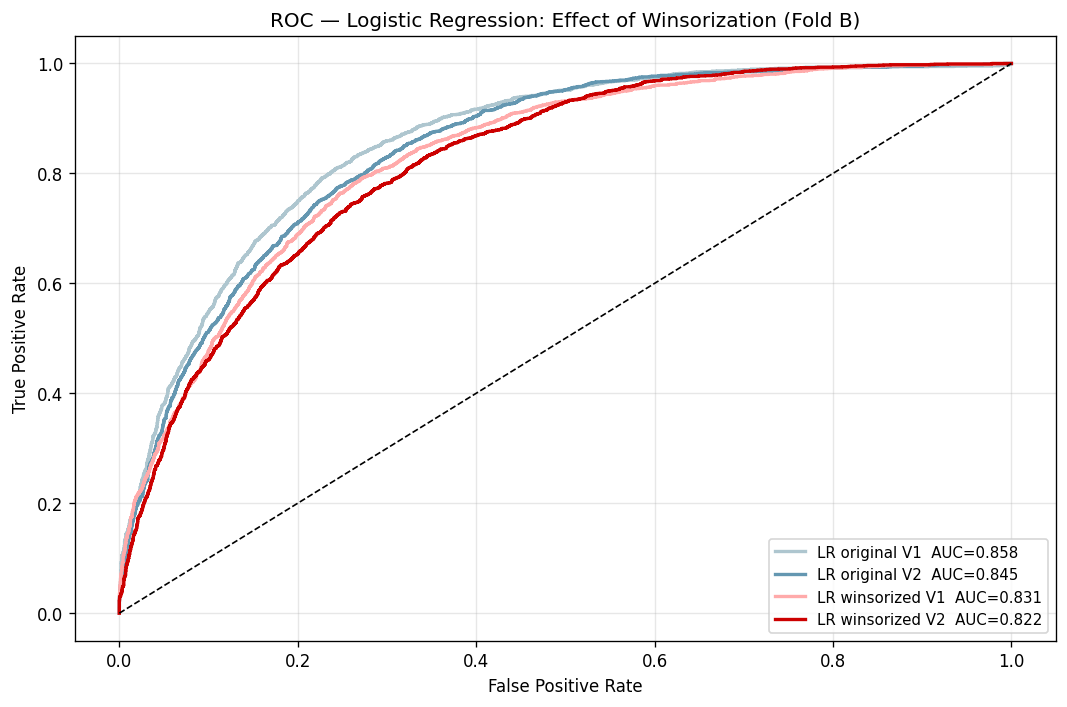

In [28]:
# --- 11a. LR comparison: plain vs. winsorized, V1 vs. V2 (Fold B) ---

# Collect all LR Fold B results together
lr_rows = []

# Original LR V1
orig_lr_v1 = next(r for r in binary_results if r['model'] == 'LogisticRegression' and r['fold'] == 'B')
lr_rows.append({'variant': 'LR_original_V1',    'auc': orig_lr_v1['auc'], 'f1': orig_lr_v1['f1'],
                'precision': orig_lr_v1['precision'], 'recall': orig_lr_v1['recall']})

# Original LR V2
orig_lr_v2 = next(r for r in binary_results_v2 if r['model'] == 'LogisticRegression' and r['fold'] == 'B')
lr_rows.append({'variant': 'LR_original_V2',    'auc': orig_lr_v2['auc'], 'f1': orig_lr_v2['f1'],
                'precision': orig_lr_v2['precision'], 'recall': orig_lr_v2['recall']})

# Winsorized LR V1
win_v1 = next(r for r in win_binary_results if r['model'] == 'LR_winsorized_V1' and r['fold'] == 'B')
lr_rows.append({'variant': 'LR_winsorized_V1',  'auc': win_v1['auc'], 'f1': win_v1['f1'],
                'precision': win_v1['precision'], 'recall': win_v1['recall']})

# Winsorized LR V2
win_v2 = next(r for r in win_binary_results if r['model'] == 'LR_winsorized_V2' and r['fold'] == 'B')
lr_rows.append({'variant': 'LR_winsorized_V2',  'auc': win_v2['auc'], 'f1': win_v2['f1'],
                'precision': win_v2['precision'], 'recall': win_v2['recall']})

lr_compare = pd.DataFrame(lr_rows).set_index('variant')
print('Logistic Regression — Effect of Winsorization (Fold B):')
print(lr_compare.round(4).to_string())
print()

# Best RF/GB for context
print('Best tree models for context (Fold B, V2):')
for r in sorted(fold_B_v2, key=lambda x: x['auc'], reverse=True):
    if r['model'] != 'LogisticRegression':
        print(f"  {r['model']:22s}  AUC={r['auc']:.4f}  F1={r['f1']:.4f}")

# ROC comparison
fig, ax = plt.subplots(figsize=(9, 6))
colors_lr = ['#aec6cf', '#6497b1', '#ff9999', '#cc0000']
for (_, row), color in zip(lr_compare.iterrows(), colors_lr):
    pass  # we'll plot directly using stored models

plot_pairs = [
    ('LR original V1',   lr_B,       Xs_teB,  '#aec6cf'),
    ('LR original V2',   lr_B2,      Xs_teB2, '#6497b1'),
    ('LR winsorized V1', lr_w,       Xw_teB if 'Xw_teB' in dir() else Xw_te, '#ffaaaa'),
    ('LR winsorized V2', lr_win_B2,  Xw_teB,  '#cc0000'),
]

# Recompute Xw_teB for V1 (needed for plot)
X_trB_wv1, X_teB_wv1, _, _ = make_split(train_B_mask, test_B_mask, TARGET_BIN)
Xw_trB_v1, Xw_teB_v1 = winsorize_and_scale(X_trB_wv1, X_teB_wv1)
lr_win_B1 = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
lr_win_B1.fit(Xw_trB_v1, y_trB)

plot_pairs = [
    ('LR original V1',   lr_B,       Xs_teB,     '#aec6cf'),
    ('LR original V2',   lr_B2,      Xs_teB2,    '#6497b1'),
    ('LR winsorized V1', lr_win_B1,  Xw_teB_v1,  '#ffaaaa'),
    ('LR winsorized V2', lr_win_B2,  Xw_teB,     '#cc0000'),
]

for name, model, X_te, color in plot_pairs:
    y_p = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_teB, y_p)
    auc = roc_auc_score(y_teB, y_p)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name}  AUC={auc:.3f}')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC — Logistic Regression: Effect of Winsorization (Fold B)')
ax.legend(loc='lower right', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## 12. Multi-Class Classification — V2 (No Mortgage Features)

Running the same three models on `transition_direction` (-1/0/+1) using the V2 feature set (mortgage features removed) for a complete comparison. LR uses Winsorization since the 3-class results showed it as the best multi-class model in V1.

In [29]:
multi_results_v2 = []

X_trBm2, X_teBm2, y_trBm2, y_teBm2 = make_split_v2(train_B_mask, test_B_mask, TARGET_MULTI)
Xw_trBm2, Xw_teBm2 = winsorize_and_scale(X_trBm2, X_teBm2)
Xs_trBm2, Xs_teBm2, _ = scale_split(X_trBm2, X_teBm2)

# LR — winsorized (best preprocessing for LR)
lr_Bm2 = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
lr_Bm2.fit(Xw_trBm2, y_trBm2)
multi_results_v2.append(evaluate_multi(lr_Bm2, Xw_teBm2, y_teBm2, 'LR_winsorized', 'B'))

# RF
rf_Bm2 = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                 random_state=RANDOM_STATE, n_jobs=-1)
rf_Bm2.fit(X_trBm2, y_trBm2)
multi_results_v2.append(evaluate_multi(rf_Bm2, X_teBm2, y_teBm2, 'RandomForest', 'B'))

# GB
gb_Bm2 = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05,
                                     max_depth=4, subsample=0.8,
                                     random_state=RANDOM_STATE)
gb_Bm2.fit(X_trBm2, y_trBm2)
multi_results_v2.append(evaluate_multi(gb_Bm2, X_teBm2, y_teBm2, 'GradientBoosting', 'B'))

print('Multi-class V2 complete.')

Multi-class V2 complete.


In [30]:
# --- 12a. V1 vs V2 multi-class comparison ---
multi_v1_df = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')} for r in multi_results
]).set_index('model').drop(columns='fold')

multi_v2_df = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')} for r in multi_results_v2
]).set_index('model').drop(columns='fold')

print('Multi-Class V1 (with mortgage features):')
print(multi_v1_df.round(4).to_string())
print()
print('Multi-Class V2 (no mortgage, LR winsorized):')
print(multi_v2_df.round(4).to_string())
print()

# Delta
v1_lr = multi_v1_df.loc['LogisticRegression', 'macro_f1']
v2_lr = multi_v2_df.loc['LR_winsorized', 'macro_f1']
print(f'LR macro F1:  V1={v1_lr:.4f}  V2 (winsorized, no mortgage)={v2_lr:.4f}  Δ={v2_lr - v1_lr:+.4f}')

Multi-Class V1 (with mortgage features):
                    macro_f1  accuracy  f1_down  f1_stable  f1_up
model                                                            
LogisticRegression    0.5614    0.5591   0.6209     0.4240 0.6391
RandomForest          0.3970    0.5089   0.0528     0.6163 0.5220
GradientBoosting      0.5022    0.5176   0.4037     0.4840 0.6189

Multi-Class V2 (no mortgage, LR winsorized):
                  macro_f1  accuracy  f1_down  f1_stable  f1_up
model                                                          
LR_winsorized       0.4668    0.5061   0.6771     0.1450 0.5782
RandomForest        0.4221    0.4911   0.1191     0.5315 0.6157
GradientBoosting    0.4834    0.4897   0.4945     0.3814 0.5743

LR macro F1:  V1=0.5614  V2 (winsorized, no mortgage)=0.4668  Δ=-0.0946


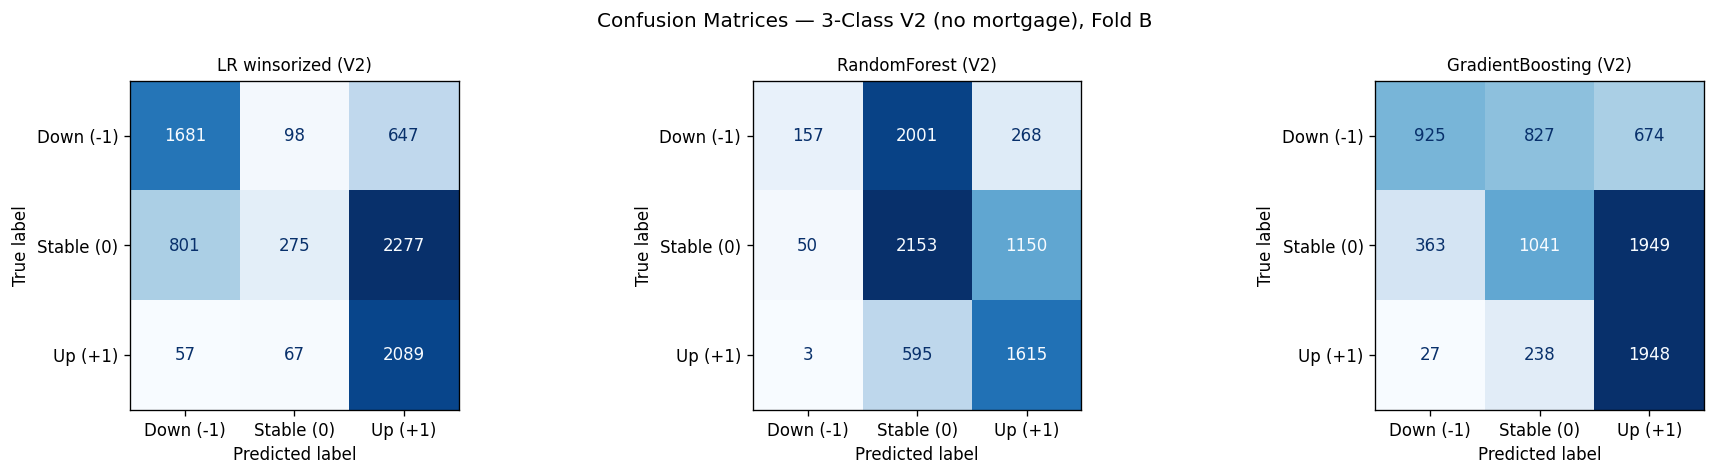

Best multi-class V2 model: GradientBoosting

              precision    recall  f1-score   support

   Down (-1)       0.70      0.38      0.49      2426
  Stable (0)       0.49      0.31      0.38      3353
     Up (+1)       0.43      0.88      0.57      2213

    accuracy                           0.49      7992
   macro avg       0.54      0.52      0.48      7992
weighted avg       0.54      0.49      0.47      7992



In [31]:
# --- 12b. Confusion matrices — best multi-class V2 model ---
best_multi_v2_name = multi_v2_df['macro_f1'].idxmax()
best_multi_v2_map  = {
    'LR_winsorized'  : (lr_Bm2,  Xw_teBm2),
    'RandomForest'   : (rf_Bm2,  X_teBm2),
    'GradientBoosting': (gb_Bm2, X_teBm2),
}
best_multi_v2_model, best_multi_v2_X = best_multi_v2_map[best_multi_v2_name]
y_pred_best_multi_v2 = best_multi_v2_model.predict(best_multi_v2_X)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, X_te, model) in zip(axes, [
    ('LR winsorized', Xw_teBm2, lr_Bm2),
    ('RandomForest',  X_teBm2,  rf_Bm2),
    ('GradientBoosting', X_teBm2, gb_Bm2),
]):
    cm = confusion_matrix(y_teBm2, model.predict(X_te), labels=[-1, 0, 1])
    ConfusionMatrixDisplay(cm, display_labels=['Down (-1)', 'Stable (0)', 'Up (+1)']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name} (V2)', fontsize=10)

plt.suptitle('Confusion Matrices — 3-Class V2 (no mortgage), Fold B', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Best multi-class V2 model: {best_multi_v2_name}')
print()
print(classification_report(y_teBm2, y_pred_best_multi_v2,
                             labels=[-1, 0, 1],
                             target_names=['Down (-1)', 'Stable (0)', 'Up (+1)']))

---
## 13. Feature Selection — RFECV + V3 Model

### Motivation

Permutation importance (Section 10) flagged 25 features with negative scores. However, negative permutation importance can mean **redundancy** rather than irrelevance — when a feature is shuffled, the model compensates by leaning harder on a correlated feature, which can appear as a small improvement. Simply cutting all negative-importance features risks removing real-world signal that is expressed through a correlated proxy.

**Recursive Feature Elimination with Cross-Validation (RFECV)** is more principled:

1. Start with all features
2. Fit a Random Forest; rank features by mean decrease in impurity
3. Remove the lowest-ranked feature(s)
4. Repeat, using walk-forward CV to score each candidate set
5. Select the feature count that maximizes AUC across the CV folds

**Key design choice:** The CV splits passed to RFECV are our own walk-forward folds (Fold A + Fold B), not random k-fold. This ensures the feature selection respects temporal ordering and does not leak future information.

### New features added (v3 vs. v2)

Four annual YoY growth rate features are included for the first time in this run:
- `business_establishments_yoy_pct`
- `total_employment_yoy_pct`
- `median_household_income_yoy_pct`
- `median_gross_rent_yoy_pct`

These capture *how fast* a neighborhood's economic fundamentals are changing, not just their level.

In [32]:
from sklearn.feature_selection import RFECV

# --- 13a. Build V3 feature set (V2 + 4 new YoY features) ---
MORTGAGE_FEATURES = ['mortgage_rate_30yr', 'mortgage_arm_spread']
YOY_NEW = [
    'business_establishments_yoy_pct',
    'total_employment_yoy_pct',
    'median_household_income_yoy_pct',
    'median_gross_rent_yoy_pct',
]
FEATURE_COLS_V3 = [c for c in FEATURE_COLS if c not in MORTGAGE_FEATURES]
print(f'V2 feature count: {len(FEATURE_COLS) - len(MORTGAGE_FEATURES)}')
print(f'V3 feature count: {len(FEATURE_COLS_V3)}  (adds {len(YOY_NEW)} YoY growth features)')
print(f'New YoY features: {YOY_NEW}')
print()

# Confirm all new features are present
missing = [c for c in YOY_NEW if c not in FEATURE_COLS_V3]
if missing:
    print(f'WARNING: missing from V3: {missing}')
else:
    print('All 4 new YoY features confirmed in V3 feature set.')

V2 feature count: 69
V3 feature count: 69  (adds 4 YoY growth features)
New YoY features: ['business_establishments_yoy_pct', 'total_employment_yoy_pct', 'median_household_income_yoy_pct', 'median_gross_rent_yoy_pct']

All 4 new YoY features confirmed in V3 feature set.


In [33]:
# --- 13b. RFECV on V3 features using walk-forward folds ---
# Walk-forward CV splits (row indices into the full df)
train_A_idx = np.where(train_A_mask)[0]
test_A_idx  = np.where(test_A_mask)[0]
train_B_idx = np.where(train_B_mask)[0]
test_B_idx  = np.where(test_B_mask)[0]

wf_cv_splits = [
    (train_A_idx, test_A_idx),
    (train_B_idx, test_B_idx),
]

X_v3 = df[FEATURE_COLS_V3].values
y_bin = df[TARGET_BIN].values

rf_for_rfe = RandomForestClassifier(
    n_estimators=150, max_depth=12, min_samples_leaf=20,
    n_jobs=-1, random_state=42
)

rfecv = RFECV(
    estimator=rf_for_rfe,
    step=3,                       # remove 3 features per iteration
    min_features_to_select=10,    # stop at 10 features minimum
    cv=wf_cv_splits,
    scoring='roc_auc',
    n_jobs=-1,
)

print(f'Running RFECV on {len(FEATURE_COLS_V3)} V3 features...')
print('(Using walk-forward Fold A + Fold B as CV splits)')
rfecv.fit(X_v3, y_bin)

n_selected = rfecv.n_features_
selected_mask = rfecv.support_
selected_features = [f for f, s in zip(FEATURE_COLS_V3, selected_mask) if s]
dropped_features  = [f for f, s in zip(FEATURE_COLS_V3, selected_mask) if not s]

print(f'\nRFECV selected: {n_selected} features  (dropped: {len(dropped_features)})')
print(f'CV AUC at optimal size: {rfecv.cv_results_["mean_test_score"].max():.4f}')

Running RFECV on 69 V3 features...
(Using walk-forward Fold A + Fold B as CV splits)



RFECV selected: 39 features  (dropped: 30)
CV AUC at optimal size: 0.7045


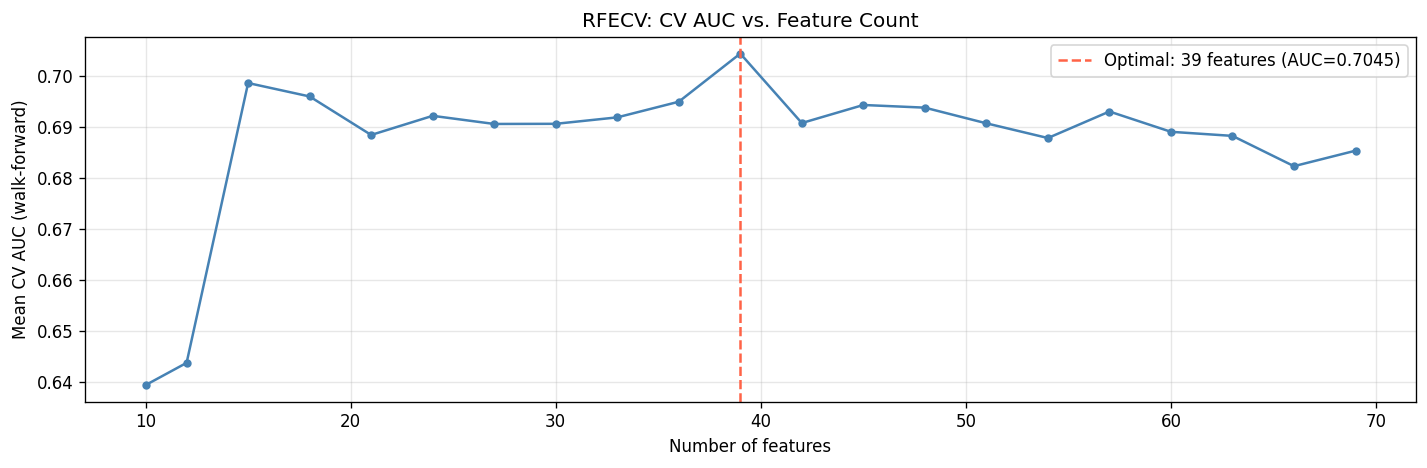


Dropped 30 features:
  - avg_pay_per_employee
  - avg_sale_to_list_ratio_lag3
  - business_establishments
  - business_establishments_yoy_pct
  - cluster
  - inventory_accel
  - inventory_mom_pct
  - inventory_mom_pct_lag3
  - inventory_mom_pct_lag6
  - inventory_vs_baseline_lag6
  - median_days_on_market
  - median_gross_rent_yoy_pct
  - median_household_income_yoy_pct
  - owner_occupancy_rate
  - pct_above_list_3m_avg
  - rent_to_income_ratio
  - sale_price_accel
  - sale_price_mom_12m_avg
  - sale_price_mom_3m_avg
  - sale_price_mom_3m_std
  - sale_price_mom_pct
  - sale_price_mom_pct_lag3
  - sale_price_mom_pct_lag6
  - sale_price_vs_baseline
  - sale_price_vs_baseline_lag3
  - sale_price_vs_baseline_lag6
  - sale_price_yoy_pct
  - sale_to_list_3m_avg
  - total_employment
  - total_employment_yoy_pct

Retained 39 features:
  + adjusted_gross_income
  + avg_sale_to_list_ratio
  + avg_sale_to_list_ratio_lag6
  + dom_vs_baseline
  + home_value_accel
  + home_value_index
  + home_valu

In [34]:
# --- 13c. RFECV AUC curve ---
cv_scores    = rfecv.cv_results_['mean_test_score']
n_feat_range = rfecv.cv_results_['n_features']   # sklearn provides this directly

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(n_feat_range, cv_scores, 'o-', color='steelblue', markersize=4)
ax.axvline(n_selected, color='tomato', linestyle='--', linewidth=1.5,
           label=f'Optimal: {n_selected} features (AUC={cv_scores.max():.4f})')
ax.set_xlabel('Number of features')
ax.set_ylabel('Mean CV AUC (walk-forward)')
ax.set_title('RFECV: CV AUC vs. Feature Count')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\nDropped {len(dropped_features)} features:')
for f in sorted(dropped_features):
    print(f'  - {f}')

print(f'\nRetained {len(selected_features)} features:')
for f in sorted(selected_features):
    tag = ' *** NEW ***' if f in YOY_NEW else ''
    print(f'  + {f}{tag}')

In [35]:
# --- 13d. Train V3 final model on RFECV-selected features, evaluate on Fold B ---
def make_split_v3(train_mask, test_mask, target):
    X_train = df.loc[train_mask, selected_features].values
    X_test  = df.loc[test_mask,  selected_features].values
    y_train = df.loc[train_mask, target].values
    y_test  = df.loc[test_mask,  target].values
    return X_train, X_test, y_train, y_test

models_v3 = {
    'RF_V3': RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_leaf=20,
        n_jobs=-1, random_state=42
    ),
    'GB_V3': GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, min_samples_leaf=20, random_state=42
    ),
}

v3_results = []
X_trBv3, X_teBv3, y_trBv3, y_teBv3 = make_split_v3(train_B_mask, test_B_mask, TARGET_BIN)

for name, clf in models_v3.items():
    clf.fit(X_trBv3, y_trBv3)
    prob = clf.predict_proba(X_teBv3)[:, 1]
    auc  = roc_auc_score(y_teBv3, prob)
    v3_results.append({'model': name, 'n_features': len(selected_features), 'auc_fold_b': auc})
    print(f'{name}: AUC = {auc:.4f}  ({len(selected_features)} features)')

v3_df = pd.DataFrame(v3_results)

RF_V3: AUC = 0.8072  (39 features)


GB_V3: AUC = 0.8519  (39 features)


In [36]:
# --- 13f. Save GB_V3 binary predictions ---
gb_v3_clf = models_v3["GB_V3"]
prob_v3 = gb_v3_clf.predict_proba(X_teBv3)[:, 1]

out_v3 = df.loc[test_B_mask, ["zip", "month", "cluster", "cluster_name",
                               "transition_next_12m", "transition_direction"]].copy()
out_v3 = out_v3.reset_index(drop=True)
out_v3["prob_transition"] = prob_v3

V3_PREDS_PATH = "../data/processed/model_predictions_v3.csv"
out_v3.to_csv(V3_PREDS_PATH, index=False)
print(f"Saved: {V3_PREDS_PATH}  shape: {out_v3.shape}")
print(f"ZIPs: {out_v3["zip"].nunique()}, Months: {out_v3["month"].nunique()}")
print(f"Avg prob_transition: {prob_v3.mean():.4f}")


Saved: ../data/processed/model_predictions_v3.csv  shape: (7992, 7)
ZIPs: 666, Months: 12
Avg prob_transition: 0.4722


In [37]:
# --- 13e. Summary comparison: V1 vs V2 vs V3 ---
# Retrieve V1 and V2 best AUC from earlier sections
v1_best_auc = fold_B_results[0]['auc']   # Section 3 best binary RF V1
v2_best_auc = fold_B_v2[0]['auc']        # Section 9 best binary RF V2
v3_best_auc = v3_df['auc_fold_b'].max()
v3_best_n   = v3_df.loc[v3_df['auc_fold_b'].idxmax(), 'n_features']

comparison = pd.DataFrame([
    {'version': 'V1 (all features incl. mortgage)',   'n_features': len(FEATURE_COLS),          'auc_fold_b': v1_best_auc},
    {'version': 'V2 (no mortgage)',                    'n_features': len(FEATURE_COLS) - 2,      'auc_fold_b': v2_best_auc},
    {'version': 'V3 (RFECV-selected + YoY features)', 'n_features': int(v3_best_n),             'auc_fold_b': v3_best_auc},
])
comparison['delta_vs_v1'] = comparison['auc_fold_b'] - v1_best_auc
comparison['delta_vs_v2'] = comparison['auc_fold_b'] - v2_best_auc

print('=== Model Version Comparison (Fold B AUC) ===')
print(comparison[['version','n_features','auc_fold_b','delta_vs_v1']].to_string(index=False))
print()

# Highlight whether new YoY features survived RFECV
yoy_survived = [f for f in YOY_NEW if f in selected_features]
yoy_dropped  = [f for f in YOY_NEW if f not in selected_features]
print(f'New YoY features retained by RFECV ({len(yoy_survived)}/4): {yoy_survived}')
if yoy_dropped:
    print(f'New YoY features dropped by RFECV:                       {yoy_dropped}')

print()
print('Interpretation:')
print(f'  V3 uses {v3_best_n} features vs. {len(FEATURE_COLS)-2} in V2.')
delta = v3_best_auc - v2_best_auc
if abs(delta) < 0.005:
    print(f'  AUC difference vs V2: {delta:+.4f} — negligible, V3 is more parsimonious.')
elif delta > 0:
    print(f'  AUC improvement vs V2: {delta:+.4f} — RFECV-selected features genuinely help.')
else:
    print(f'  AUC change vs V2: {delta:+.4f} — small cost for a cleaner feature set.')

=== Model Version Comparison (Fold B AUC) ===
                           version  n_features  auc_fold_b  delta_vs_v1
  V1 (all features incl. mortgage)          71      0.8607       0.0000
                  V2 (no mortgage)          69      0.8473      -0.0134
V3 (RFECV-selected + YoY features)          39      0.8519      -0.0088

New YoY features retained by RFECV (0/4): []
New YoY features dropped by RFECV:                       ['business_establishments_yoy_pct', 'total_employment_yoy_pct', 'median_household_income_yoy_pct', 'median_gross_rent_yoy_pct']

Interpretation:
  V3 uses 39 features vs. 69 in V2.
  AUC difference vs V2: +0.0046 — negligible, V3 is more parsimonious.


---
## 14. Multi-Class Direction Model — V3 (RFECV Features)

### Motivation

The binary model answers: *"Will this ZIP transition upward?"*  
The multi-class model answers: *"Which direction will it go — up, stable, or down?"*

For a property investment tool, both predictions matter:
- **Upward transition (↑):** Buy signal — neighborhood is about to heat up
- **Downward transition (↓):** Avoid / sell signal — neighborhood is softening
- **Stable (→):** Hold / monitor

We train the same V3 feature set (10 RFECV-selected features) on `transition_direction` (−1 / 0 / +1) using Fold B walk-forward validation.

**Output metric:** Macro F1 — averages F1 across all three classes equally, appropriate since each class has real decision value and we don't want to overweight the majority (stable) class.

**Key derived output:**  
`net_direction = prob_up − prob_down` — a single value from −1 to +1 that summarizes the model's directional confidence. Used as the diverging map color scale in the Streamlit app.

In [38]:
from sklearn.metrics import f1_score, classification_report

# --- 14a. Train multi-class models on V3 features (Fold B) ---
def make_split_multi_v3(train_mask, test_mask):
    X_train = df.loc[train_mask, selected_features].values
    X_test  = df.loc[test_mask,  selected_features].values
    y_train = df.loc[train_mask, TARGET_MULTI].values.astype(int)
    y_test  = df.loc[test_mask,  TARGET_MULTI].values.astype(int)
    return X_train, X_test, y_train, y_test

X_trBm3, X_teBm3, y_trBm3, y_teBm3 = make_split_multi_v3(train_B_mask, test_B_mask)

multi_models_v3 = {
    'RF_multi_V3': RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_leaf=20,
        n_jobs=-1, random_state=42
    ),
    'GB_multi_V3': GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        subsample=0.8, min_samples_leaf=20, random_state=42
    ),
}

multi_results_v3 = []
best_multi_clf = None
best_multi_f1  = -1
best_multi_name = ''

for name, clf in multi_models_v3.items():
    clf.fit(X_trBm3, y_trBm3)
    preds = clf.predict(X_teBm3)
    f1 = f1_score(y_teBm3, preds, average='macro')
    multi_results_v3.append({'model': name, 'macro_f1': f1})
    print(f'{name}: macro F1 = {f1:.4f}')
    if f1 > best_multi_f1:
        best_multi_f1   = f1
        best_multi_clf  = clf
        best_multi_name = name

print(f'\nBest multi-class V3 model: {best_multi_name}  (macro F1 = {best_multi_f1:.4f})')

RF_multi_V3: macro F1 = 0.4234


GB_multi_V3: macro F1 = 0.5076

Best multi-class V3 model: GB_multi_V3  (macro F1 = 0.5076)


In [39]:
# --- 14b. Classification report + confusion matrix ---
best_preds = best_multi_clf.predict(X_teBm3)
print(f'Classification Report — {best_multi_name} (Fold B test set)\n')
print(classification_report(
    y_teBm3, best_preds,
    target_names=['Down (-1)', 'Stable (0)', 'Up (+1)'],
    digits=3,
))

# Confusion matrix
cm = pd.crosstab(
    pd.Series(y_teBm3,   name='Actual'),
    pd.Series(best_preds, name='Predicted'),
    rownames=['Actual'], colnames=['Predicted'],
)
cm.index   = ['Down (-1)', 'Stable (0)', 'Up (+1)']
cm.columns = ['Pred Down', 'Pred Stable', 'Pred Up']
print('Confusion matrix (rows=actual, cols=predicted):')
print(cm)

Classification Report — GB_multi_V3 (Fold B test set)

              precision    recall  f1-score   support

   Down (-1)      0.690     0.434     0.533      2426
  Stable (0)      0.506     0.326     0.397      3353
     Up (+1)      0.449     0.873     0.593      2213

    accuracy                          0.511      7992
   macro avg      0.548     0.545     0.508      7992
weighted avg      0.546     0.511     0.492      7992

Confusion matrix (rows=actual, cols=predicted):
            Pred Down  Pred Stable  Pred Up
Down (-1)        1053          812      561
Stable (0)        449         1094     1810
Up (+1)            25          255     1933


In [40]:
# --- 14c. Save multi-class predictions with per-class probabilities ---
# class order from the fitted classifier: -1, 0, +1
class_order = best_multi_clf.classes_   # should be [-1, 0, 1]
print(f'Class order: {class_order}')

proba = best_multi_clf.predict_proba(X_teBm3)  # shape (n, 3)
idx_down   = list(class_order).index(-1)
idx_stable = list(class_order).index(0)
idx_up     = list(class_order).index(1)

out_multi = df.loc[test_B_mask, ['zip', 'month', 'cluster', 'cluster_name',
                                  'transition_next_12m', 'transition_direction']].copy()
out_multi['prob_down']      = proba[:, idx_down]
out_multi['prob_stable']    = proba[:, idx_stable]
out_multi['prob_up']        = proba[:, idx_up]
out_multi['pred_direction'] = best_multi_clf.predict(X_teBm3)
out_multi['net_direction']  = out_multi['prob_up'] - out_multi['prob_down']

out_multi.to_csv('../data/processed/model_predictions_multiclass.csv', index=False)
print(f'Saved model_predictions_multiclass.csv  shape={out_multi.shape}')
print(f'\nNet direction score range: [{out_multi["net_direction"].min():.3f}, {out_multi["net_direction"].max():.3f}]')
print(f'\nPredicted class distribution (Fold B):')
print(out_multi['pred_direction'].value_counts().sort_index().rename({-1:'Down',0:'Stable',1:'Up'}))

Class order: [-1  0  1]
Saved model_predictions_multiclass.csv  shape=(7992, 11)

Net direction score range: [-0.994, 0.998]

Predicted class distribution (Fold B):
pred_direction
Down      1527
Stable    2161
Up        4304
Name: count, dtype: int64


---
## 15. SHAP Values — Per-ZIP Prediction Explanations

TreeExplainer computes exact Shapley values for the GB_V3 binary classifier.
Each SHAP value represents the contribution of a feature to pushing the
predicted log-odds up (positive) or down (negative) relative to the base rate.

Output: **shap_values.csv** — one row per ZIP-month, 10 SHAP columns + base value.
Used in the Streamlit app ZIP Deep Dive to show *why* a ZIP scored high or low.

In [41]:
import shap

gb_v3_clf = models_v3["GB_V3"]
explainer  = shap.TreeExplainer(gb_v3_clf)

# Compute SHAP values for the Fold B test set
# For sklearn GBM binary: returns shape (n_samples, n_features) in log-odds space
shap_explanation = explainer(X_teBv3)

vals = shap_explanation.values
if vals.ndim == 3:
    vals = vals[:, :, 1]   # positive-class slice if 3D

base_val = shap_explanation.base_values
if hasattr(base_val, "__len__"):
    base_val = float(base_val[0])
else:
    base_val = float(base_val)

# Build output: zip, month, shap_<feature>, shap_base
shap_df = df.loc[test_B_mask, ["zip", "month"]].copy().reset_index(drop=True)
for i, feat in enumerate(selected_features):
    shap_df[f"shap_{feat}"] = vals[:, i]
shap_df["shap_base"] = base_val

SHAP_PATH = "../data/processed/shap_values.csv"
shap_df.to_csv(SHAP_PATH, index=False)

print(f"Saved: {SHAP_PATH}")
print(f"Shape: {shap_df.shape}")
print(f"Base value (log-odds of base rate): {base_val:.4f}")
print(f"Rows: {shap_df['zip'].nunique()} ZIPs x {shap_df['month'].nunique()} months")
print()
print("SHAP column means (avg absolute contribution):")
shap_cols = [c for c in shap_df.columns if c.startswith("shap_") and c != "shap_base"]
print(shap_df[shap_cols].abs().mean().sort_values(ascending=False).round(4).to_string())

Saved: ../data/processed/shap_values.csv
Shape: (7992, 42)
Base value (log-odds of base rate): -1.8639
Rows: 666 ZIPs x 12 months

SHAP column means (avg absolute contribution):
shap_home_value_mom_pct            1.1885
shap_home_value_vs_baseline_lag6   0.5833
shap_homes_sold                    0.4475
shap_pct_sold_above_list           0.4188
shap_pct_off_market_in_2wks        0.2343
shap_pct_sold_above_list_lag6      0.2228
shap_median_household_income       0.2166
shap_inventory_mom_12m_avg         0.2143
shap_home_value_mom_pct_lag6       0.1995
shap_median_owner_home_value       0.1747
shap_home_value_mom_pct_lag3       0.1696
shap_inventory_yoy_pct             0.1600
shap_dom_vs_baseline               0.1578
shap_median_sale_price             0.1576
shap_pct_sold_above_list_lag3      0.1496
shap_median_gross_rent             0.1426
shap_taxable_interest_income       0.1388
shap_inventory_vs_baseline_lag3    0.1312
shap_median_price_per_sqft         0.1280
shap_home_value_mom_3m_s

---
## 16. Monthly-Only Model (Zillow + Redfin, No Annual Census/IRS Data)

Drop all 17 annual-source features (ACS, CBP, IRS). Same 666 ZIPs, same 2021 test period.
Enables future extension to 2012+ Redfin/Zillow history and removes annual data lag.


In [ ]:
# --- 16a. Define monthly-only feature set ---
ANNUAL_FEATURES = {
    "median_owner_home_value", "median_household_income", "median_gross_rent",
    "owner_occupancy_rate", "business_establishments", "total_employment",
    "avg_pay_per_employee",
    "tax_returns_filed", "adjusted_gross_income", "taxable_interest_income",
    "price_to_income_ratio", "rent_to_income_ratio", "price_to_rent_ratio",
    "business_establishments_yoy_pct", "total_employment_yoy_pct",
    "median_household_income_yoy_pct", "median_gross_rent_yoy_pct",
}

FEATURE_COLS_MONTHLY = [f for f in FEATURE_COLS_V3 if f not in ANNUAL_FEATURES]
print(f"V3 features:      {len(FEATURE_COLS_V3)}")
print(f"Annual dropped:   {len(ANNUAL_FEATURES & set(FEATURE_COLS_V3))}")
print(f"Monthly features: {len(FEATURE_COLS_MONTHLY)}")

# --- 16b. RFECV on monthly-only features ---
print("
Running RFECV on monthly-only features...")
X_monthly = df[FEATURE_COLS_MONTHLY].values

rfecv_m = RFECV(
    estimator=RandomForestClassifier(
        n_estimators=150, max_depth=12, min_samples_leaf=20,
        n_jobs=-1, random_state=42
    ),
    step=3, min_features_to_select=10,
    cv=wf_cv_splits, scoring="roc_auc", n_jobs=-1
)
rfecv_m.fit(X_monthly, y_bin)

selected_monthly = [f for f, s in zip(FEATURE_COLS_MONTHLY, rfecv_m.support_) if s]
print(f"RFECV selected: {len(selected_monthly)} features")
print(f"CV AUC at optimal size: {rfecv_m.cv_results_['mean_test_score'].max():.4f}")
print("Selected:", selected_monthly)

# --- 16c. Train GB binary on monthly-only features ---
def make_split_monthly(train_mask, test_mask, target):
    X_train = df.loc[train_mask, selected_monthly].values
    X_test  = df.loc[test_mask,  selected_monthly].values
    y_train = df.loc[train_mask, target].values
    y_test  = df.loc[test_mask,  target].values
    return X_train, X_test, y_train, y_test

X_trB_m, X_teB_m, y_trB_m, y_teB_m = make_split_monthly(train_B_mask, test_B_mask, TARGET_BIN)

gb_monthly = GradientBoostingClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.8, min_samples_leaf=20, random_state=42
)
gb_monthly.fit(X_trB_m, y_trB_m)
prob_m = gb_monthly.predict_proba(X_teB_m)[:, 1]
auc_m  = roc_auc_score(y_teB_m, prob_m)
v3_auc = v3_df[v3_df["model"] == "GB_V3"]["auc_fold_b"].values[0]
print(f"
GB Monthly-only  AUC (Fold B): {auc_m:.4f}")
print(f"GB V3 (all sources) AUC:       {v3_auc:.4f}")

# --- 16d. Multi-class monthly-only ---
X_trB_mm, X_teB_mm, y_trB_mm, y_teB_mm = make_split_monthly(train_B_mask, test_B_mask, TARGET_MULTI)
y_trB_mm = y_trB_mm.astype(int)
y_teB_mm = y_teB_mm.astype(int)

gb_multi_monthly = GradientBoostingClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    subsample=0.8, min_samples_leaf=20, random_state=42
)
gb_multi_monthly.fit(X_trB_mm, y_trB_mm)
pred_mm = gb_multi_monthly.predict(X_teB_mm)
f1_mm   = f1_score(y_teB_mm, pred_mm, average="macro")
print(f"GB Monthly multi-class Macro F1: {f1_mm:.4f}")

# multi-class for V3 comparison
v3_multi_f1 = max(r["f1"] for r in multi_results_v3)
print(f"GB V3 multi-class Macro F1:      {v3_multi_f1:.4f}")

# --- 16e. Save binary predictions ---
out_m = df.loc[test_B_mask, ["zip", "month", "cluster", "cluster_name",
                              "transition_next_12m", "transition_direction"]].copy()
out_m = out_m.reset_index(drop=True)
out_m["prob_transition"] = prob_m
out_m.to_csv("../data/processed/model_predictions_monthly.csv", index=False)
print(f"
Saved model_predictions_monthly.csv  {out_m.shape}")

# --- 16f. Save multi-class predictions ---
class_order_m = gb_multi_monthly.classes_
proba_m = gb_multi_monthly.predict_proba(X_teB_mm)
idx_d = list(class_order_m).index(-1)
idx_s = list(class_order_m).index(0)
idx_u = list(class_order_m).index(1)

out_mm = df.loc[test_B_mask, ["zip", "month", "cluster", "cluster_name",
                               "transition_next_12m", "transition_direction"]].copy()
out_mm = out_mm.reset_index(drop=True)
out_mm["prob_down"]      = proba_m[:, idx_d]
out_mm["prob_stable"]    = proba_m[:, idx_s]
out_mm["prob_up"]        = proba_m[:, idx_u]
out_mm["pred_direction"] = gb_multi_monthly.predict(X_teB_mm)
out_mm["net_direction"]  = out_mm["prob_up"] - out_mm["prob_down"]
out_mm.to_csv("../data/processed/model_predictions_multiclass_monthly.csv", index=False)
print(f"Saved model_predictions_multiclass_monthly.csv  {out_mm.shape}")

# --- 16g. SHAP for monthly model ---
import shap as _shap
explainer_m = _shap.TreeExplainer(gb_monthly)
shap_exp_m  = explainer_m(X_teB_m)
vals_m = shap_exp_m.values
if vals_m.ndim == 3:
    vals_m = vals_m[:, :, 1]
base_m = float(shap_exp_m.base_values[0]) if hasattr(shap_exp_m.base_values, "__len__") else float(shap_exp_m.base_values)

shap_df_m = df.loc[test_B_mask, ["zip", "month"]].copy().reset_index(drop=True)
for i, feat in enumerate(selected_monthly):
    shap_df_m[f"shap_{feat}"] = vals_m[:, i]
shap_df_m["shap_base"] = base_m
shap_df_m.to_csv("../data/processed/shap_values_monthly.csv", index=False)
print(f"Saved shap_values_monthly.csv  {shap_df_m.shape}")

# --- 16h. Save comparison metadata for the app ---
import json as _json
comparison_meta = {
    "v3": {
        "label": "V3 (All Sources)",
        "n_features": len(selected_features),
        "auc": round(float(v3_auc), 4),
        "f1":  round(float(v3_multi_f1), 4),
        "features": selected_features,
    },
    "monthly": {
        "label": "Monthly-Only (Zillow + Redfin)",
        "n_features": len(selected_monthly),
        "auc": round(float(auc_m), 4),
        "f1":  round(float(f1_mm), 4),
        "features": selected_monthly,
    },
    "winner": "v3" if v3_auc >= auc_m else "monthly",
}
with open("../data/processed/model_comparison.json", "w") as _f:
    _json.dump(comparison_meta, _f, indent=2)
print("Saved model_comparison.json")
print(f"
WINNER: {comparison_meta['winner'].upper()}  (V3 AUC={v3_auc:.4f}  Monthly AUC={auc_m:.4f})")
